<a href="https://colab.research.google.com/github/wenshinsu/credit-card-transaction-classification/blob/main/Credit_Card_Transaction_Classification_(Fraud_VS_Legitimate).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as nm
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from google.colab import files
uploaded = files.upload()
data_set= pd.read_csv('fraud_data.csv')

Saving fraud_data.csv to fraud_data.csv


In [ ]:
data_set.info()
#14446 rows of data
#15 columns
#data type need to change to correct format

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14446 entries, 0 to 14445
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  14446 non-null  object 
 1   merchant               14446 non-null  object 
 2   category               14446 non-null  object 
 3   amt                    14446 non-null  float64
 4   city                   14446 non-null  object 
 5   state                  14446 non-null  object 
 6   lat                    14446 non-null  float64
 7   long                   14446 non-null  float64
 8   city_pop               14446 non-null  int64  
 9   job                    14446 non-null  object 
 10  dob                    14446 non-null  object 
 11  trans_num              14446 non-null  object 
 12  merch_lat              14446 non-null  float64
 13  merch_long             14446 non-null  float64
 14  is_fraud               14446 non-null  object 
dtypes:

In [ ]:
data_set['is_fraud'].value_counts()
# To check how many values are in is_fraud

,count
is_fraud,
0,12600
1,1844
"1""2020-12-24 16:56:24""",1
"0""2019-01-01 00:00:44""",1


In [ ]:
# Show the first 10 unique raw values in the column
print("Raw 'trans_date_trans_time' values (first 10):")
print(data_set['trans_date_trans_time'].astype(str).unique()[:10])

Raw 'trans_date_trans_time' values (first 10):
['04-01-2019 00:58' '04-01-2019 15:06' '04-01-2019 22:37'
 '04-01-2019 23:06' '04-01-2019 23:59' '05-01-2019 03:15'
 '05-01-2019 03:21' '05-01-2019 11:31' '05-01-2019 18:03'
 '05-01-2019 22:02']


In [ ]:
# Convert columns to string type
string_cols = ['merchant', 'category', 'city', 'state', 'job', 'trans_num']
data_set[string_cols] = data_set[string_cols].astype(str)

# Convert columns to integer type
data_set['is_fraud'] = data_set['is_fraud'].astype(str).str.strip()
data_set = data_set[data_set['is_fraud'].isin(['0', '1'])]
data_set['is_fraud'] = data_set['is_fraud'].astype(int)

int_cols = ['is_fraud', 'city_pop']
data_set[int_cols] = data_set[int_cols].astype(int)

# Convert columns to float type
float_cols = ['lat', 'long', 'merch_lat', 'merch_long', 'amt']
data_set[float_cols] = data_set[float_cols].astype(float)

# Clean and convert 'dob' to datetime
data_set['dob'] = pd.to_datetime(data_set['dob'], dayfirst=True, errors='coerce')

# ✅ FLEXIBLE CLEANING for trans_date_trans_time
cleaned_datetime = data_set['trans_date_trans_time'].astype(str)
cleaned_datetime = cleaned_datetime.str.replace('"', '', regex=False) \
                                   .str.replace(r'\s+', ' ', regex=True) \
                                   .str.strip()

# Use flexible parsing (no fixed format)
data_set['trans_date_trans_time'] = pd.to_datetime(
    cleaned_datetime,
    dayfirst=True,
    errors='coerce'
)

# Confirm data types
print(" Cleaned & Updated Data Types:")
print(data_set.dtypes)

# Optional: Check how many still failed
print("\n Missing values in 'trans_date_trans_time':", data_set['trans_date_trans_time'].isna().sum())

data_set.shape


/tmp/ipython-input-5-2003030607.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_set['is_fraud'] = data_set['is_fraud'].astype(int)
/tmp/ipython-input-5-2003030607.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_set[int_cols] = data_set[int_cols].astype(int)
/tmp/ipython-input-5-2003030607.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://p

 Cleaned & Updated Data Types:
trans_date_trans_time    datetime64[ns]
merchant                         object
category                         object
amt                             float64
city                             object
state                            object
lat                             float64
long                            float64
city_pop                          int64
job                              object
dob                      datetime64[ns]
trans_num                        object
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
dtype: object

 Missing values in 'trans_date_trans_time': 0


(14444, 15)

In [ ]:
# Check total missing values per column
print("Missing Values Per Column:")
print(data_set.isnull().sum())

# Optional: Total number of missing cells
total_missing = data_set.isnull().sum().sum()
print(f"\nTotal missing values in dataset: {total_missing}")

# Check number of duplicate rows
duplicate_count = data_set.duplicated().sum()
print(f"\nTotal duplicate rows: {duplicate_count}")

# Optional: View duplicate rows (if needed)
if duplicate_count > 0:
    print("\nHere are the duplicate rows:")
    display(data_set[data_set.duplicated()])

data_set.shape

Missing Values Per Column:
trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

Total missing values in dataset: 0

Total duplicate rows: 63

Here are the duplicate rows:


,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
8725,2019-01-04 00:58:00,"""Stokes, Christiansen and Sipes""",grocery_net,14.37,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",1939-11-09,a3806e984cec6ac0096d8184c64ad3a1,65.654142,-164.722603,1
8857,2019-01-04 15:06:00,Predovic Inc,shopping_net,966.11,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",1939-11-09,a59185fe1b9ccf21323f581d7477573f,65.468863,-165.473127,1
8964,2019-01-04 22:37:00,Wisozk and Sons,misc_pos,49.61,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",1939-11-09,86ba3a888b42cd3925881fa34177b4e0,65.347667,-165.914542,1
8972,2019-01-04 23:06:00,Murray-Smitham,grocery_pos,295.26,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",1939-11-09,3a068fe1d856f0ecedbed33e4b5f4496,64.445035,-166.080207,1
8982,2019-01-04 23:59:00,Friesen Lt,health_fitness,18.17,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",1939-11-09,891cdd1191028759dc20dc224347a0ff,65.447094,-165.446843,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13261,2019-01-18 14:38:00,Shanahan-Lehne,personal_care,21.54,Thompson,UT,38.9999,-109.6150,46,"""Surveyor, minerals""",1987-04-23,ce3b2734ce646ef6a47b3484a8e043e5,38.211376,-109.986757,1
13372,2019-01-18 22:06:00,Beier LLC,entertainment,528.98,Thompson,UT,38.9999,-109.6150,46,"""Surveyor, minerals""",1987-04-23,3417f366e2e1d5dd25a3a89a3aae9f3d,39.164469,-109.933543,1
13376,2019-01-18 22:12:00,Bartoletti and Sons,personal_care,21.23,Thompson,UT,38.9999,-109.6150,46,"""Surveyor, minerals""",1987-04-23,2df9fa2d0e508ed2a83aa3ac6f4b5d5a,38.998205,-110.005615,1
13392,2019-01-18 23:16:00,Ankunding-Carroll,travel,9.33,Thompson,UT,38.9999,-109.6150,46,"""Surveyor, minerals""",1987-04-23,a0ed41246d201717db7250fa2375c73b,39.230640,-108.990363,1


(14444, 15)

In [ ]:
#  Remove duplicate rows
data_set = data_set.drop_duplicates()

#  Show remaining number of rows
print(" Number of rows after removing duplicates:", len(data_set))

# Optional: preview the cleaned data
print("\n First 3 rows:")
print(data_set.head())

 Number of rows after removing duplicates: 14381

 First 3 rows:
  trans_date_trans_time                          merchant        category  \
0   2019-01-04 00:58:00  "Stokes, Christiansen and Sipes"     grocery_net   
1   2019-01-04 15:06:00                      Predovic Inc    shopping_net   
2   2019-01-04 22:37:00                   Wisozk and Sons        misc_pos   
3   2019-01-04 23:06:00                    Murray-Smitham     grocery_pos   
4   2019-01-04 23:59:00                        Friesen Lt  health_fitness   

      amt   city state      lat      long  city_pop  \
0   14.37  Wales    AK  64.7556 -165.6723       145   
1  966.11  Wales    AK  64.7556 -165.6723       145   
2   49.61  Wales    AK  64.7556 -165.6723       145   
3  295.26  Wales    AK  64.7556 -165.6723       145   
4   18.17  Wales    AK  64.7556 -165.6723       145   

                          job        dob                         trans_num  \
0  "Administrator, education" 1939-11-09  a3806e984cec6ac0096d8

In [ ]:
def check_value_ranges(data_set):
    issues = {}

    # Check datetime columns: should not be NaT (if mandatory)
    for col in ['trans_date_trans_time', 'dob']:
        missing_mask = data_set[col].isna()
        if missing_mask.any():
            issues[col] = data_set[missing_mask]
            print(f"\nMissing values found in datetime column '{col}': {missing_mask.sum()} rows")
        else:
            print(f"No missing values in datetime column '{col}'.")

    # Latitude: must be between -90 and 90
    lat_mask = data_set['lat'].isna() | (data_set['lat'] < -90) | (data_set['lat'] > 90)
    if lat_mask.any():
        issues['lat'] = data_set[lat_mask]
        print(f"\nInvalid latitude values: {lat_mask.sum()} rows")
    else:
        print("Latitude values are within valid range.")

    # Longitude: must be between -180 and 180
    long_mask = data_set['long'].isna() | (data_set['long'] < -180) | (data_set['long'] > 180)
    if long_mask.any():
        issues['long'] = data_set[long_mask]
        print(f"\nInvalid longitude values: {long_mask.sum()} rows")
    else:
        print("Longitude values are within valid range.")

    # Merchant latitude
    merch_lat_mask = data_set['merch_lat'].isna() | (data_set['merch_lat'] < -90) | (data_set['merch_lat'] > 90)
    if merch_lat_mask.any():
        issues['merch_lat'] = data_set[merch_lat_mask]
        print(f"\nInvalid merchant latitude values: {merch_lat_mask.sum()} rows")
    else:
        print("Merchant latitude values are within valid range.")

    # Merchant longitude
    merch_long_mask = data_set['merch_long'].isna() | (data_set['merch_long'] < -180) | (data_set['merch_long'] > 180)
    if merch_long_mask.any():
        issues['merch_long'] = data_set[merch_long_mask]
        print(f"\nInvalid merchant longitude values: {merch_long_mask.sum()} rows")
    else:
        print("Merchant longitude values are within valid range.")

    # City population: must be positive
    city_pop_mask = data_set['city_pop'].isna() | (data_set['city_pop'] <= 0)
    if city_pop_mask.any():
        issues['city_pop'] = data_set[city_pop_mask]
        print(f"\nInvalid city population values: {city_pop_mask.sum()} rows")
    else:
        print("City population values are valid.")

    # Amount: must be non-negative
    amt_mask = data_set['amt'].isna() | (data_set['amt'] < 0)
    if amt_mask.any():
        issues['amt'] = data_set[amt_mask]
        print(f"\nInvalid transaction amount values: {amt_mask.sum()} rows")
    else:
        print("Transaction amount values are valid.")

    return issues


# Ensure 'is_fraud' is numeric
data_set['is_fraud'] = pd.to_numeric(data_set['is_fraud'], errors='coerce')

# Identify and display invalid 'is_fraud' values
mask = data_set['is_fraud'].notna() & (~data_set['is_fraud'].isin([0, 1]))
weird_is_fraud_rows = data_set[mask]

print("\n=== Check for Invalid 'is_fraud' Values ===")
if weird_is_fraud_rows.empty:
    print("No suspicious values found in 'is_fraud' column.")
else:
    print("Rows where 'is_fraud' is NOT 0 or 1:")
    print(weird_is_fraud_rows)

# Run the value check
print("\n=== Running Value Checks ===")
value_issues = check_value_ranges(data_set)

# Print summary
print("\n=== Summary of Suspicious Values ===")
if not value_issues:
    print("No suspicious values found in the dataset.")
else:
    for col, rows in value_issues.items():
        print(f"\nSuspicious values found in column '{col}': {len(rows)} rows")
        print(rows.head())


=== Check for Invalid 'is_fraud' Values ===
No suspicious values found in 'is_fraud' column.

=== Running Value Checks ===
No missing values in datetime column 'trans_date_trans_time'.
No missing values in datetime column 'dob'.
Latitude values are within valid range.
Longitude values are within valid range.
Merchant latitude values are within valid range.
Merchant longitude values are within valid range.
City population values are valid.
Transaction amount values are valid.

=== Summary of Suspicious Values ===
No suspicious values found in the dataset.


/tmp/ipython-input-8-1481918687.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_set['is_fraud'] = pd.to_numeric(data_set['is_fraud'], errors='coerce')


In [ ]:
from datetime import datetime

today = pd.Timestamp(datetime.today().date())

# Just subtract birth year from current year
data_set['age'] = today.year - data_set['dob'].dt.year

# Day of the week (e.g., Monday, Tuesday)
data_set['day_of_week'] = data_set['trans_date_trans_time'].dt.day_name()

# Extract hour from transaction time
data_set['hour'] = data_set['trans_date_trans_time'].dt.hour

def get_time_of_day(hour):
    if 4 <= hour < 8:
        return 'Dawn'
    elif 8 <= hour < 10:
        return 'Morning'
    elif 10 <= hour < 14:
        return 'Noon'
    elif 14 <= hour < 16:
        return 'Afternoon'
    elif 16 <= hour < 18:
        return 'Sunset'
    elif 18 <= hour < 22:
        return 'Evening'
    elif 22 <= hour < 24:
        return 'Night'
    else:  # 0 <= hour < 4
        return 'Midnight'

# Apply function
data_set['time_of_day'] = data_set['hour'].apply(get_time_of_day)

# Show top 3 full rows including new derived columns
print(data_set.head(3))

  trans_date_trans_time                          merchant      category  \
0   2019-01-04 00:58:00  "Stokes, Christiansen and Sipes"   grocery_net   
1   2019-01-04 15:06:00                      Predovic Inc  shopping_net   
2   2019-01-04 22:37:00                   Wisozk and Sons      misc_pos   

      amt   city state      lat      long  city_pop  \
0   14.37  Wales    AK  64.7556 -165.6723       145   
1  966.11  Wales    AK  64.7556 -165.6723       145   
2   49.61  Wales    AK  64.7556 -165.6723       145   

                          job        dob                         trans_num  \
0  "Administrator, education" 1939-11-09  a3806e984cec6ac0096d8184c64ad3a1   
1  "Administrator, education" 1939-11-09  a59185fe1b9ccf21323f581d7477573f   
2  "Administrator, education" 1939-11-09  86ba3a888b42cd3925881fa34177b4e0   

   merch_lat  merch_long  is_fraud  age day_of_week  hour time_of_day  
0  65.654142 -164.722603         1   86      Friday     0    Midnight  
1  65.468863 -165.473

/tmp/ipython-input-9-585540033.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_set['age'] = today.year - data_set['dob'].dt.year
/tmp/ipython-input-9-585540033.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_set['day_of_week'] = data_set['trans_date_trans_time'].dt.day_name()
/tmp/ipython-input-9-585540033.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

In [ ]:
def simple_age_group(age):
    if 0 <= age <= 14:
        return 'Children (0–14)'
    elif 15 <= age <= 24:
        return 'Youth (15–24)'
    elif 25 <= age <= 64:
        return 'Adults (25–64)'
    elif age >= 65:
        return 'Seniors (65+)'
    else:
        return 'Unknown'

# Apply the simplified age grouping
data_set['age_group'] = data_set['age'].apply(simple_age_group)

# Preview the result
print(data_set[['age', 'age_group']].head(10))

   age      age_group
0   86  Seniors (65+)
1   86  Seniors (65+)
2   86  Seniors (65+)
3   86  Seniors (65+)
4   86  Seniors (65+)
5   86  Seniors (65+)
6   86  Seniors (65+)
7   71  Seniors (65+)
8   86  Seniors (65+)
9   86  Seniors (65+)


/tmp/ipython-input-10-2714011033.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_set['age_group'] = data_set['age'].apply(simple_age_group)


In [ ]:
# Sort the dataset by transaction date ascending (oldest to newest)
data_set = data_set.sort_values(by='trans_date_trans_time', ascending=True).reset_index(drop=True)

# Show top 5 full rows with all columns
print(data_set.head(5))

  trans_date_trans_time        merchant       category     amt  \
0   2019-01-01 00:00:00  Lind-Buckridge  entertainment  220.11   
1   2019-01-01 00:07:00       Kiehn Inc    grocery_pos   96.29   
2   2019-01-01 00:09:00     Beier-Hyatt   shopping_pos    7.77   
3   2019-01-01 00:21:00      Bruen-Yost       misc_pos    6.85   
4   2019-01-01 00:22:00       Kunze Inc    grocery_pos   90.22   

                       city state      lat      long  city_pop  \
0                Malad City    ID  42.1808 -112.2620      4154   
1                   Grenada    CA  41.6125 -122.5258       589   
2  High Rolls Mountain Park    NM  32.9396 -105.8189       899   
3                   Freedom    WY  43.0172 -111.0292       471   
4                   Honokaa    HI  20.0827 -155.4880      4878   

                           job        dob                         trans_num  \
0  Nature conservation officer 1962-01-19  a1a22d70485983eac12b5b88dad1cf95   
1              Systems analyst 1945-12-21  41363

In [ ]:
data_set.dtypes

,0
trans_date_trans_time,datetime64[ns]
merchant,object
category,object
amt,float64
city,object
state,object
lat,float64
long,float64
city_pop,int64
job,object


/tmp/ipython-input-13-617369321.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette='viridis')


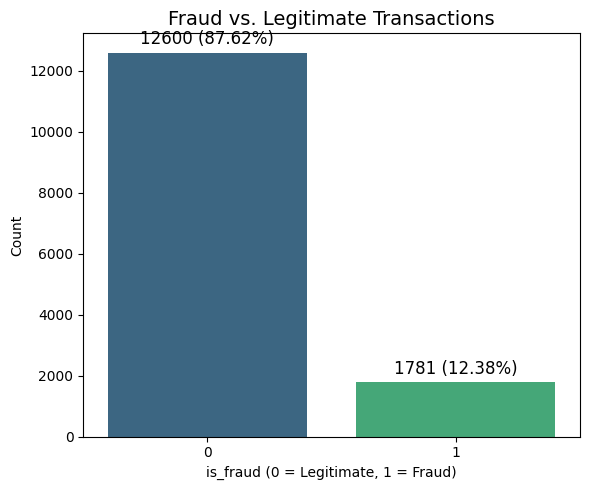

In [ ]:
#EDA

# Count the values
fraud_counts = data_set['is_fraud'].value_counts().sort_index()
total = fraud_counts.sum()
percentages = (fraud_counts / total) * 100

# Plot
plt.figure(figsize=(6, 5))
ax = sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette='viridis')

# Add value and percentage labels on top
for i, (count, pct) in enumerate(zip(fraud_counts.values, percentages.values)):
    label = f'{count} ({pct:.2f}%)'
    ax.text(i, count + total * 0.01, label, ha='center', va='bottom', fontsize=12)

# Titles and labels
plt.title('Fraud vs. Legitimate Transactions', fontsize=14)
plt.xlabel('is_fraud (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Count')
plt.xticks([0, 1])
plt.tight_layout()
plt.show()

/tmp/ipython-input-14-3755570963.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_values.values, y=top_values.index, palette='crest')


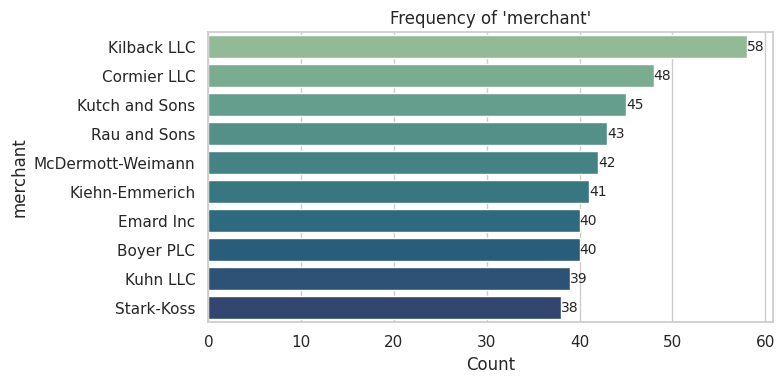

/tmp/ipython-input-14-3755570963.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_values.values, y=top_values.index, palette='crest')


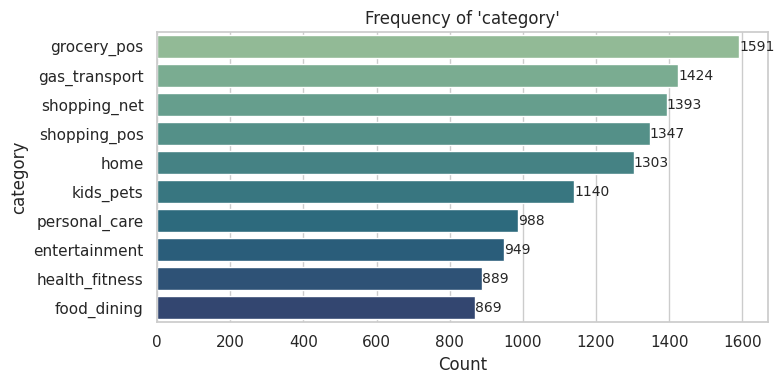

/tmp/ipython-input-14-3755570963.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_values.values, y=top_values.index, palette='crest')


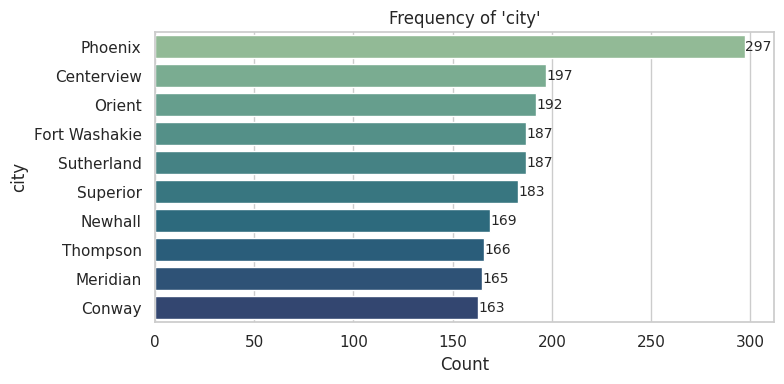

/tmp/ipython-input-14-3755570963.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_values.values, y=top_values.index, palette='crest')


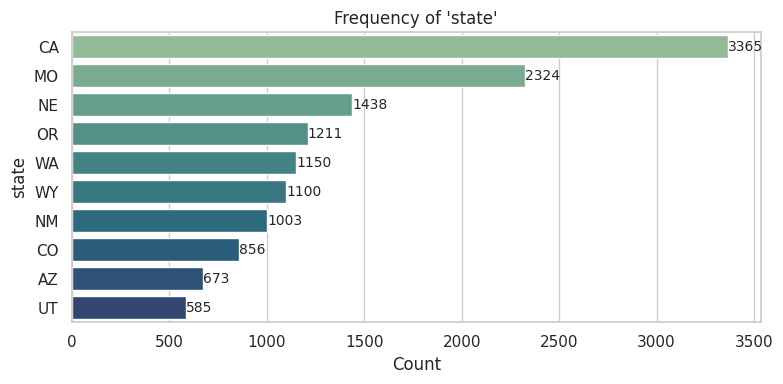

/tmp/ipython-input-14-3755570963.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_values.values, y=top_values.index, palette='crest')


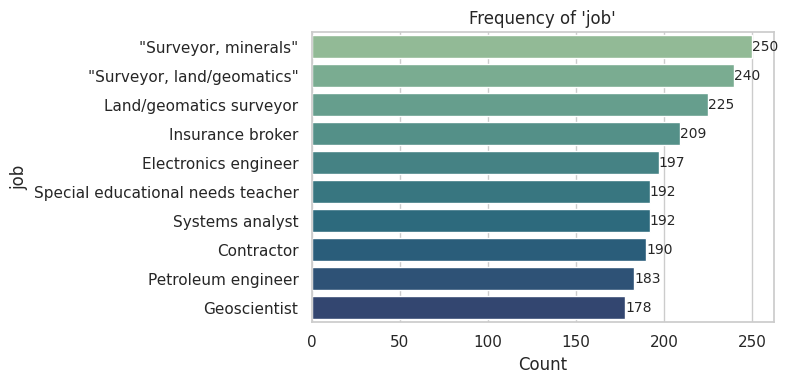

/tmp/ipython-input-14-3755570963.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_values.values, y=top_values.index, palette='crest')


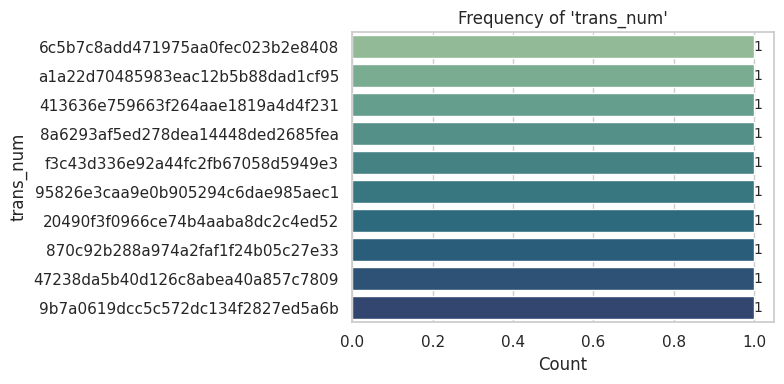

/tmp/ipython-input-14-3755570963.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_values.values, y=top_values.index, palette='crest')


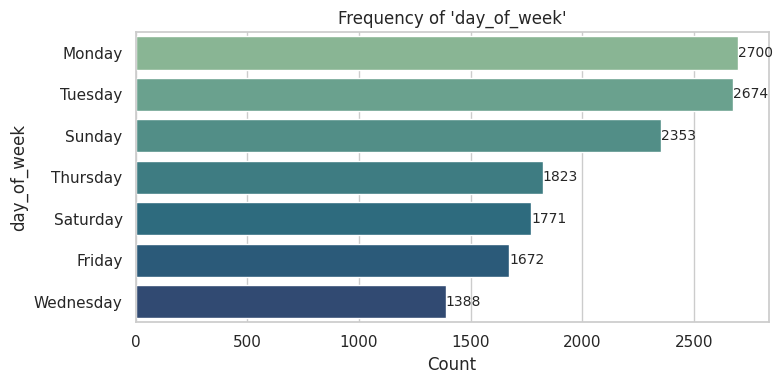

/tmp/ipython-input-14-3755570963.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_values.values, y=top_values.index, palette='crest')


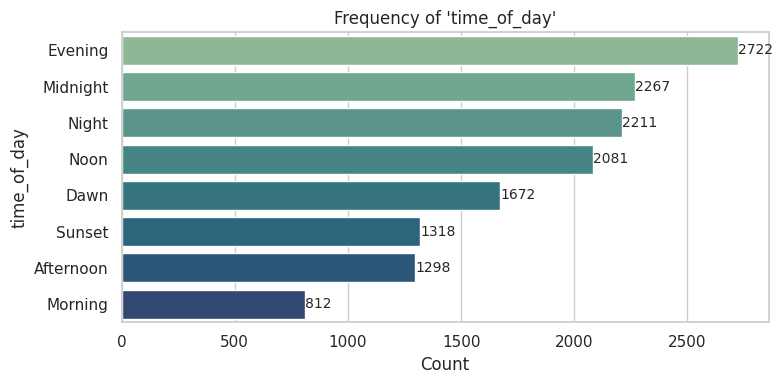

/tmp/ipython-input-14-3755570963.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_values.values, y=top_values.index, palette='crest')


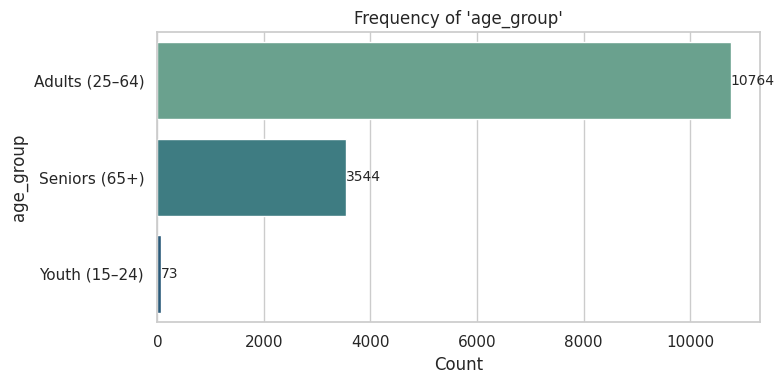

In [ ]:
# Identify categorical columns
categorical_cols = data_set.select_dtypes(include='object').columns

# Set chart style
sns.set(style="whitegrid")

# Loop through each categorical column and plot
for col in categorical_cols:
    # Get top 10 most frequent values
    top_values = data_set[col].value_counts().head(10)

    # Plot
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(x=top_values.values, y=top_values.index, palette='crest')

    # Add labels to each bar
    for i, value in enumerate(top_values.values):
        ax.text(value, i, f'{value}', va='center', ha='left', fontsize=10)

    plt.title(f"Frequency of '{col}'")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

 Skipping 'merchant' — too many categories (693)


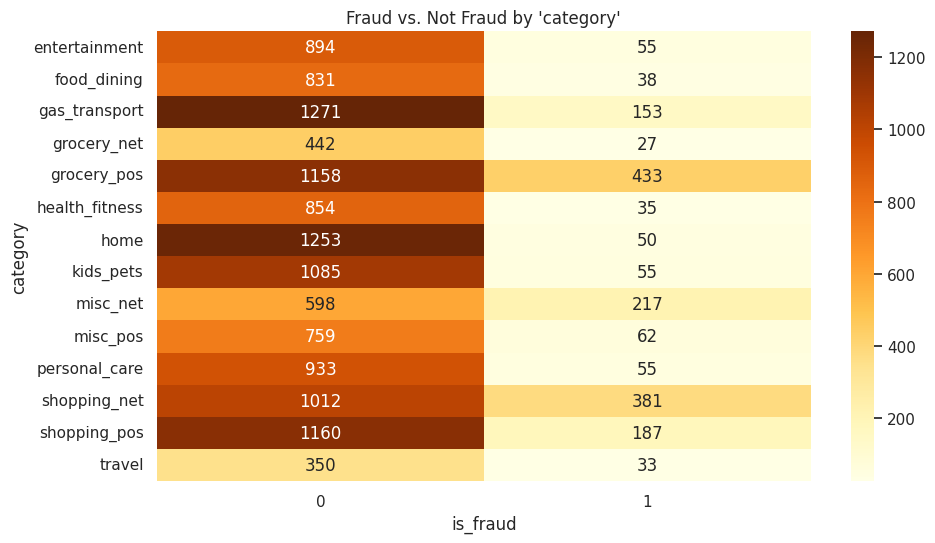

 Skipping 'city' — too many categories (176)


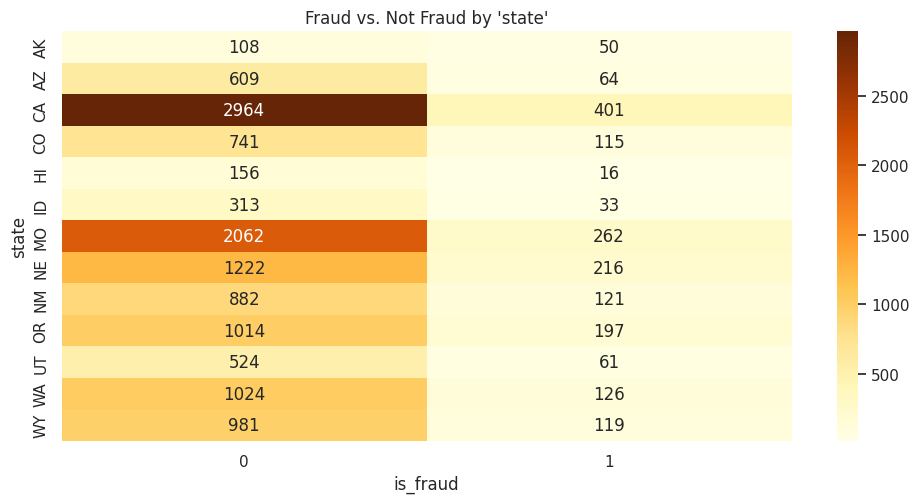

 Skipping 'job' — too many categories (163)
 Skipping 'trans_num' — too many categories (14381)


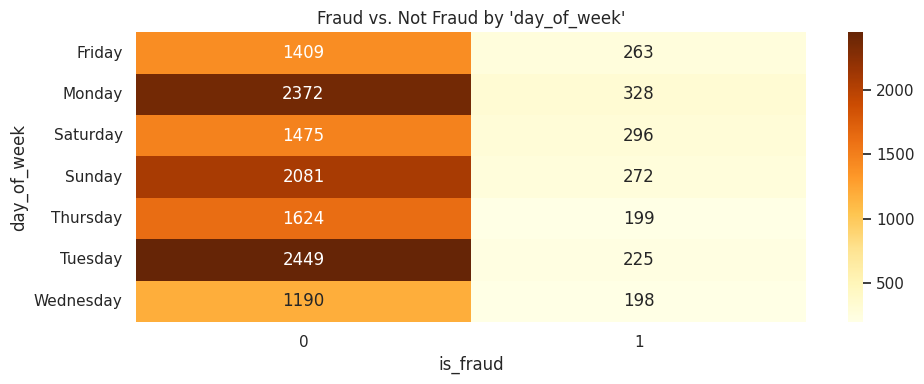

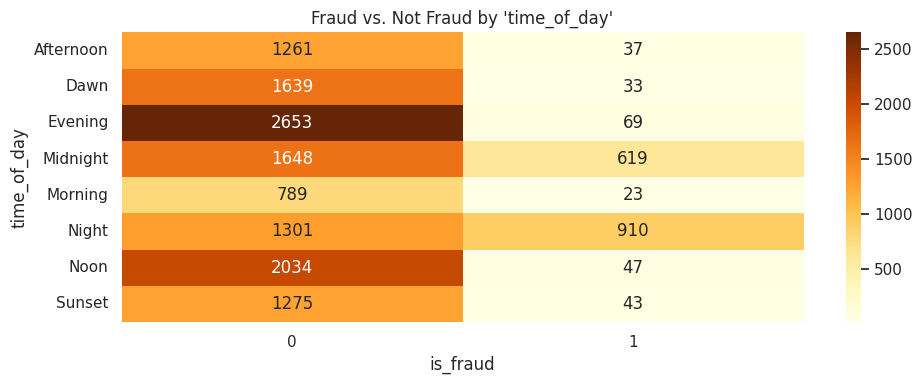

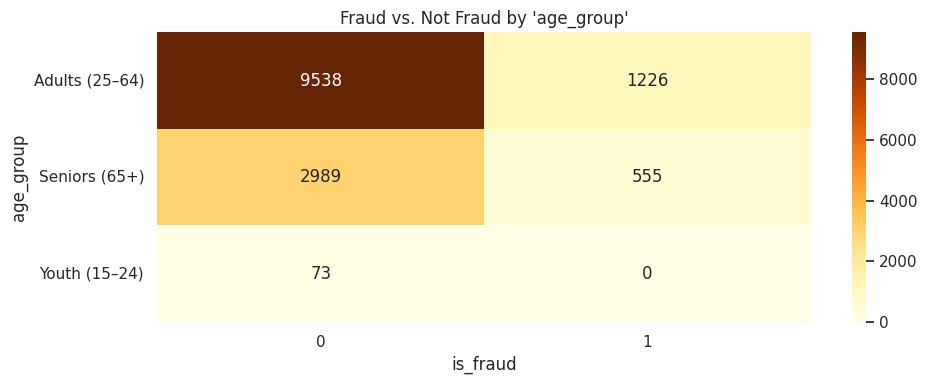

In [ ]:
# Get all categorical columns
categorical_cols = data_set.select_dtypes(include='object').columns

# Loop through each categorical column
for col in categorical_cols:
    # Create cross-tab (count of fraud vs not fraud for each category)
    fraud_ct = data_set.groupby([col, 'is_fraud']).size().unstack(fill_value=0)

    # Skip if too many unique values (for readability)
    if fraud_ct.shape[0] > 30:
        print(f" Skipping '{col}' — too many categories ({fraud_ct.shape[0]})")
        continue

    # Plot heatmap
    plt.figure(figsize=(10, max(4, fraud_ct.shape[0] * 0.4)))
    sns.heatmap(fraud_ct, annot=True, fmt='d', cmap='YlOrBr')
    plt.title(f"Fraud vs. Not Fraud by '{col}'")
    plt.xlabel("is_fraud")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [ ]:
# Columns you want to explore
cols_to_check = ['merchant', 'city', 'job']

for col in cols_to_check:
    unique_values = data_set[col].unique()
    print(f"\n Unique identifiers in '{col}':")
    print(f"Total unique: {len(unique_values)}")
    print(unique_values)  # Show all unique values


 Unique identifiers in 'merchant':
Total unique: 693
['Lind-Buckridge' 'Kiehn Inc' 'Beier-Hyatt' 'Bruen-Yost' 'Kunze Inc'
 '"Nitzsche, Kessler and Wol"' '"Kihn, Abernathy and Douglas"'
 'Ledner-Pfannerstill' 'Stracke-Lemke' 'Cummerata-Jones' 'Huel-Langworth'
 '"Ferry, Lynch and Kautze"' '"Little, Gutmann and Lynch"'
 '"Reichert, Huels and Hoppe"' '"Swaniawski, Lowe and Robel"' 'Howe Lt'
 'Wolf Inc' 'Vandervort-Funk' '"Schaefer, McGlynn and Bosco"'
 'Fisher-Schowalte' 'Medhurst PLC' 'Bauch-Rayno' 'Kerluke Inc'
 'Hills-Olson' 'Durgan-Aue' 'Pacocha-Bauch' '"Reilly, Heaney and Cole"'
 'Bradtke PLC' '"Zieme, Bode and Dooley"' 'Hills-Witting'
 '"Bernhard, Grant and Langworth"' 'Lockman Lt' 'Harber Inc'
 '"Kerluke, Kertzmann and Wiz"' '"Johnston, Nikolaus and Maggio"'
 'Torp-Labadie' 'Doyle Lt' 'McDermott-Rice' 'Spinka Inc'
 'McGlynn-Jaskolski' 'Schmitt Lt' 'Donnelly PLC'
 '"Kutch, Hermiston and Farrell"' 'Torp-Lemke' 'Kassulke PLC' 'Dach-Nade'
 '"Bins, Balistreri and Beatty"' 'Miller-Hauck'

 Top 20 Merchants Involved in Fraud:
merchant
Kiehn-Emmerich                            19
"Romaguera, Cruickshank and Greenholt"    18
Kerluke-Abshire                           17
Kunze Inc                                 16
Kilback LLC                               15
Strosin-Cruickshank                       14
Kutch and Sons                            13
"Schultz, Simonis and Little"             13
Terry-Huel                                13
McDermott-Weimann                         13
Murray-Smitham                            13
Hudson-Ratke                              12
Lockman Lt                                12
"Gottlieb, Considine and Schultz"         12
"Mosciski, Ziemann and Farrell"           11
Wolf Inc                                  11
Rempel Inc                                11
Vandervort-Funk                           10
Doyle Lt                                  10
"Quitzon, Green and Bashirian"            10
Name: count, dtype: int64


/tmp/ipython-input-17-1321383028.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_fraud_merchants.values, y=top_fraud_merchants.index, palette='Reds_r')


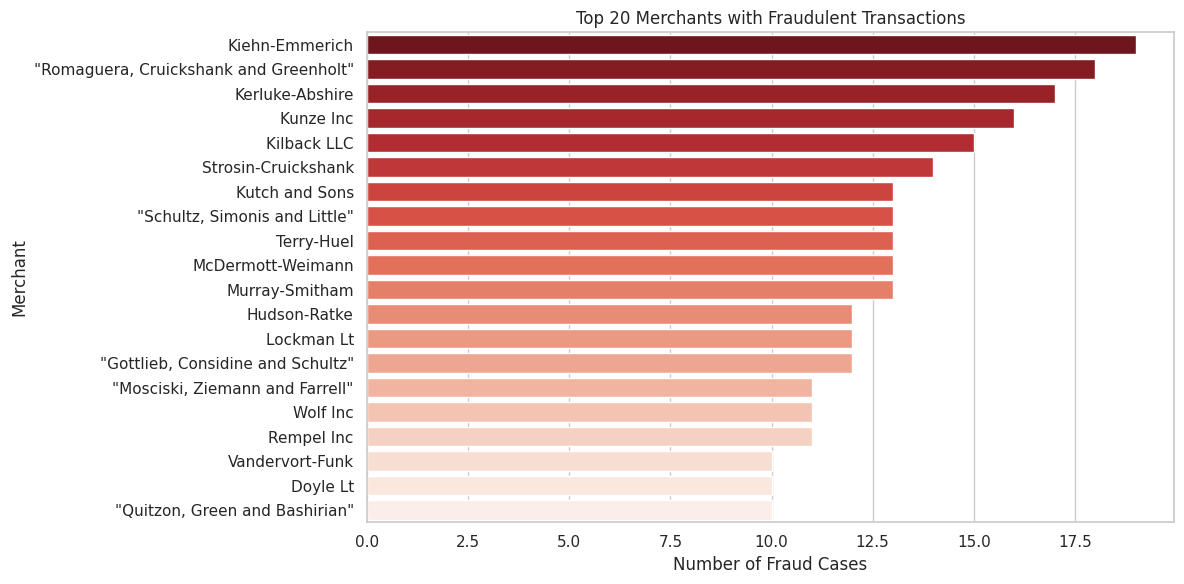

In [ ]:
# Filter fraudulent transactions
fraud_df = data_set[data_set['is_fraud'] == 1]

# Count top 20 merchants with most fraud cases
top_fraud_merchants = fraud_df['merchant'].value_counts().head(20)

# Display the result
print(" Top 20 Merchants Involved in Fraud:")
print(top_fraud_merchants)

#  Visualize as a bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=top_fraud_merchants.values, y=top_fraud_merchants.index, palette='Reds_r')
plt.xlabel("Number of Fraud Cases")
plt.ylabel("Merchant")
plt.title("Top 20 Merchants with Fraudulent Transactions")
plt.tight_layout()
plt.show()

In [ ]:
# 1. Group by merchant and calculate mean fraud rate
merchant_fraud_rate = data_set.groupby('merchant')['is_fraud'].mean()

# 2. Map this rate back to the dataset
data_set['merchant_fraud_rate'] = data_set['merchant'].map(merchant_fraud_rate)

# 3. Preview the updated dataset
print(data_set[['merchant', 'is_fraud', 'merchant_fraud_rate']].head(10))

                        merchant  is_fraud  merchant_fraud_rate
0                 Lind-Buckridge         0             0.083333
1                      Kiehn Inc         0             0.333333
2                    Beier-Hyatt         0             0.187500
3                     Bruen-Yost         0             0.045455
4                      Kunze Inc         0             0.516129
5    "Nitzsche, Kessler and Wol"         0             0.100000
6  "Kihn, Abernathy and Douglas"         0             0.235294
7            Ledner-Pfannerstill         0             0.160000
8                  Stracke-Lemke         0             0.166667
9                Cummerata-Jones         0             0.055556


Top 20 Cities Involved in Fraud:
             city  fraud_count
0     Albuquerque           24
1          Aurora           23
2   Fort Washakie           21
3            Mesa           20
4        Glendale           20
5         Hubbell           19
6         Seattle           19
7        San Jose           18
8       San Diego           18
9         Phoenix           17
10     Sacramento           16
11     North Loup           16
12        Freedom           15
13       Bay City           15
14          Tekoa           15
15     Coulee Dam           15
16          Wales           15
17       Carlotta           15
18     Mound City           15
19     Sutherland           15


/tmp/ipython-input-19-2747293394.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cities_df, x='fraud_count', y='city', palette='Reds_r')


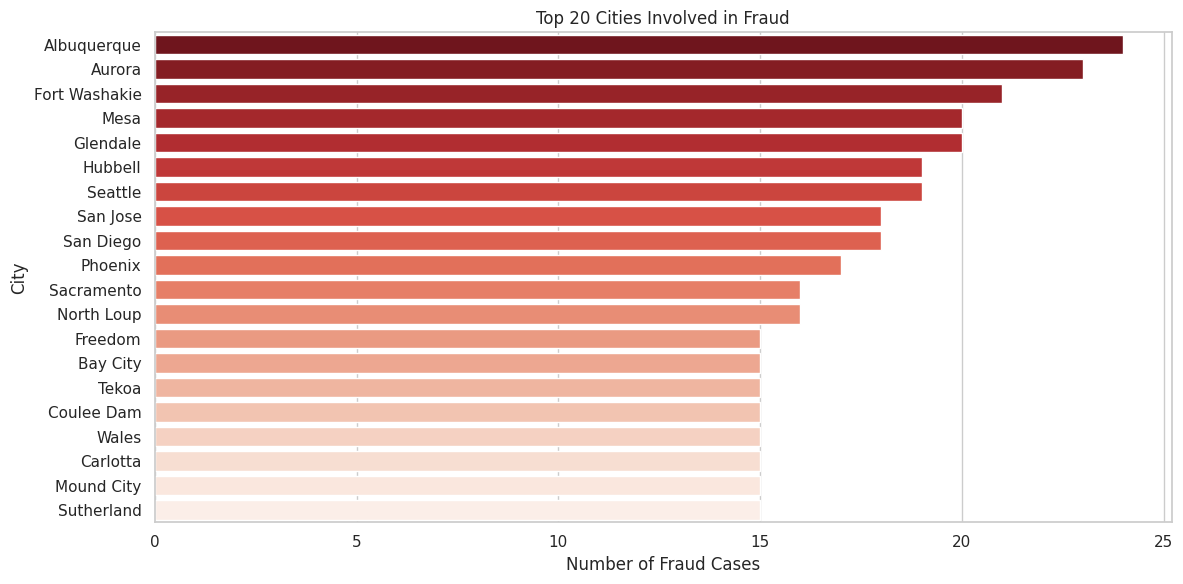

In [ ]:
# Filter for fraudulent transactions
fraud_data = data_set[data_set['is_fraud'] == 1]

# Count number of frauds per city
top_cities = fraud_data['city'].value_counts().head(20)

# Display as DataFrame
top_cities_df = top_cities.reset_index()
top_cities_df.columns = ['city', 'fraud_count']

# Show top 20
print("Top 20 Cities Involved in Fraud:")
print(top_cities_df)

# Bar chart
plt.figure(figsize=(12,6))
sns.barplot(data=top_cities_df, x='fraud_count', y='city', palette='Reds_r')
plt.title("Top 20 Cities Involved in Fraud")
plt.xlabel("Number of Fraud Cases")
plt.ylabel("City")
plt.tight_layout()
plt.show()

In [ ]:
# Calculate mean fraud rate per city
city_fraud_rate = data_set.groupby('city')['is_fraud'].mean().reset_index()
city_fraud_rate.columns = ['city', 'city_fraud_rate']

# Merge the fraud rate back into your original dataset
data_set = data_set.merge(city_fraud_rate, on='city', how='left')

In [ ]:
data_set.head(3)

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,...,merch_lat,merch_long,is_fraud,age,day_of_week,hour,time_of_day,age_group,merchant_fraud_rate,city_fraud_rate
0,2019-01-01 00:00:00,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,...,43.150704,-112.154481,0,63,Tuesday,0,Midnight,Adults (25–64),0.083333,0.258065
1,2019-01-01 00:07:00,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,...,41.657520,-122.230347,0,80,Tuesday,0,Midnight,Seniors (65+),0.333333,0.141304
2,2019-01-01 00:09:00,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,...,32.863258,-106.520205,0,58,Tuesday,0,Midnight,Adults (25–64),0.187500,0.087302


 Skipping 'merchant' — too many categories (693)


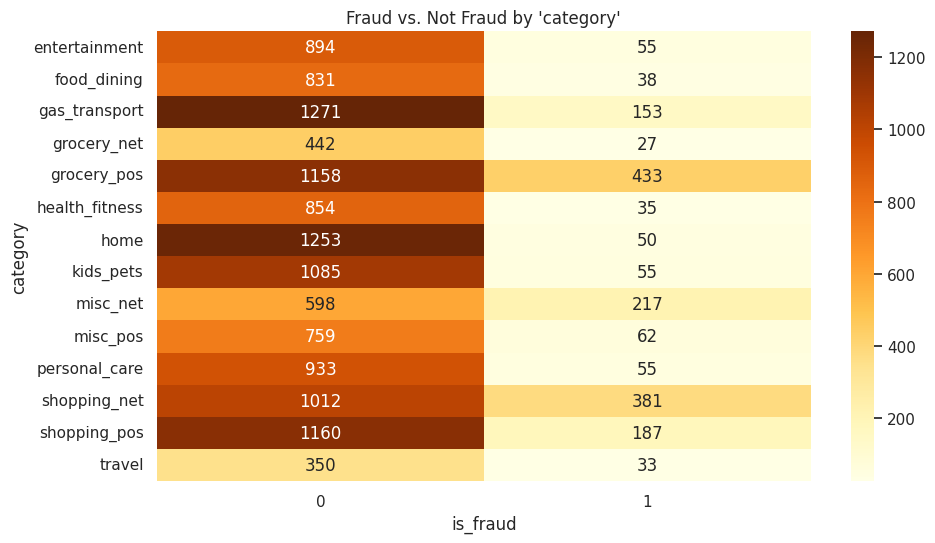

 Skipping 'city' — too many categories (176)


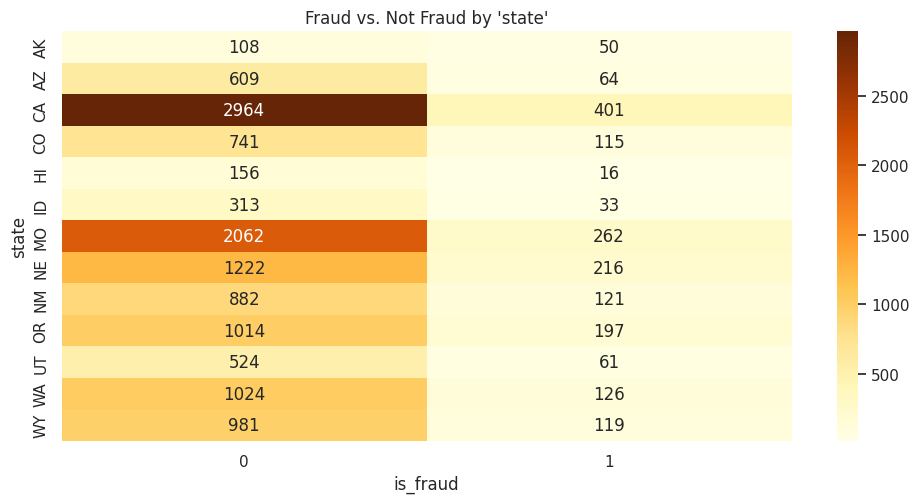

 Skipping 'job' — too many categories (163)
 Skipping 'trans_num' — too many categories (14381)


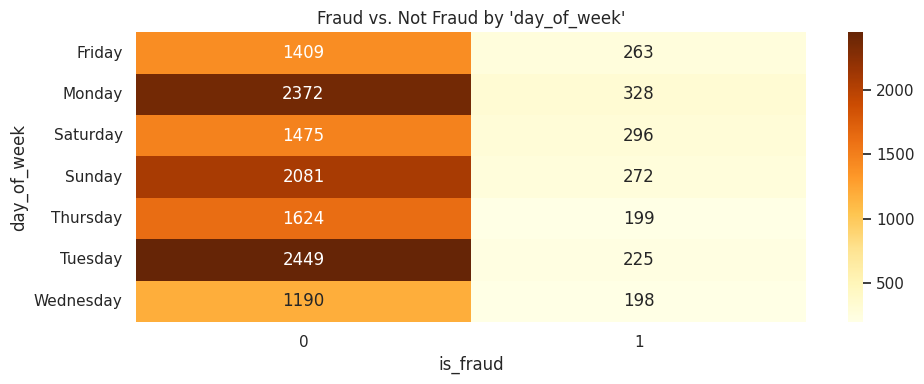

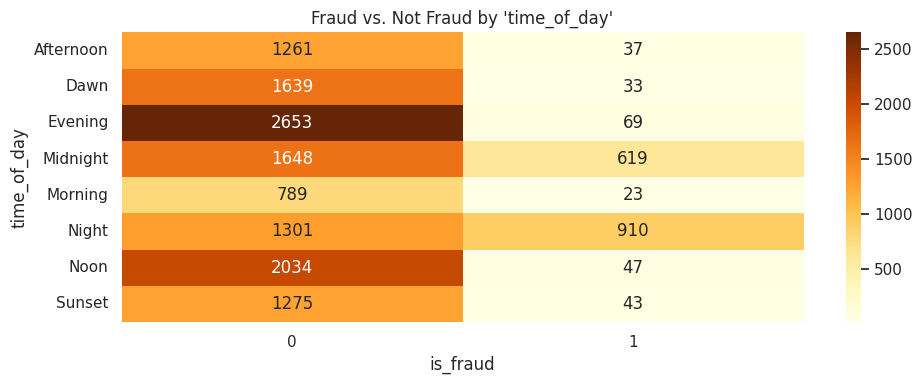

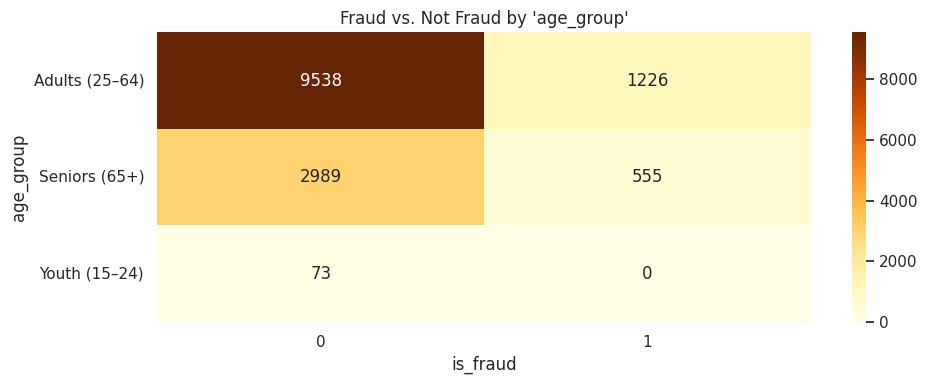

In [ ]:
# Get all categorical columns
categorical_cols = data_set.select_dtypes(include='object').columns

# Loop through each categorical column
for col in categorical_cols:
    # Create cross-tab (count of fraud vs not fraud for each category)
    fraud_ct = data_set.groupby([col, 'is_fraud']).size().unstack(fill_value=0)

    # Skip if too many unique values (for readability)
    if fraud_ct.shape[0] > 30:
        print(f" Skipping '{col}' — too many categories ({fraud_ct.shape[0]})")
        continue

    # Plot heatmap
    plt.figure(figsize=(10, max(4, fraud_ct.shape[0] * 0.4)))
    sns.heatmap(fraud_ct, annot=True, fmt='d', cmap='YlOrBr')
    plt.title(f"Fraud vs. Not Fraud by '{col}'")
    plt.xlabel("is_fraud")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


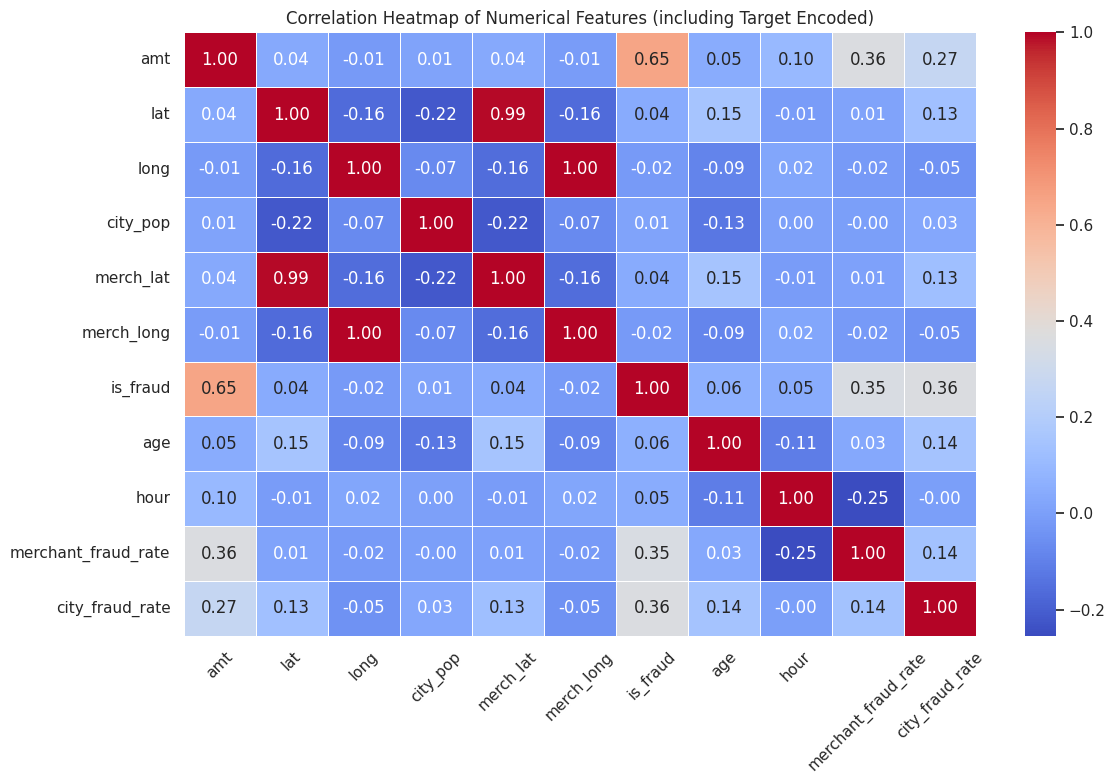

In [ ]:
# 1. Select only numeric columns
numeric_cols = data_set.select_dtypes(include=['number'])

# 2. Compute correlation matrix
corr_matrix = numeric_cols.corr()

# 3. Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features (including Target Encoded)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Top 20 Jobs Involved in Fraud:
job
Colour technologist                       29
Systems analyst                           28
"Surveyor, minerals"                      25
Network engineer                          24
Naval architect                           24
"Surveyor, land/geomatics"                24
Research scientist (physical sciences)    23
Human resources officer                   23
"Engineer, biomedical"                    22
"Scientist, audiological"                 21
Wellsite geologist                        20
Land/geomatics surveyor                   20
"Civil engineer, contracting"             19
Public relations account executive        19
Set designer                              19
Materials engineer                        19
Dealer                                    19
Educational psychologist                  18
Geoscientist                              18
"Pilot, airline"                          17
Name: count, dtype: int64


/tmp/ipython-input-24-2918199298.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_fraud_jobs.index, x=top_fraud_jobs.values, palette='Reds_r')


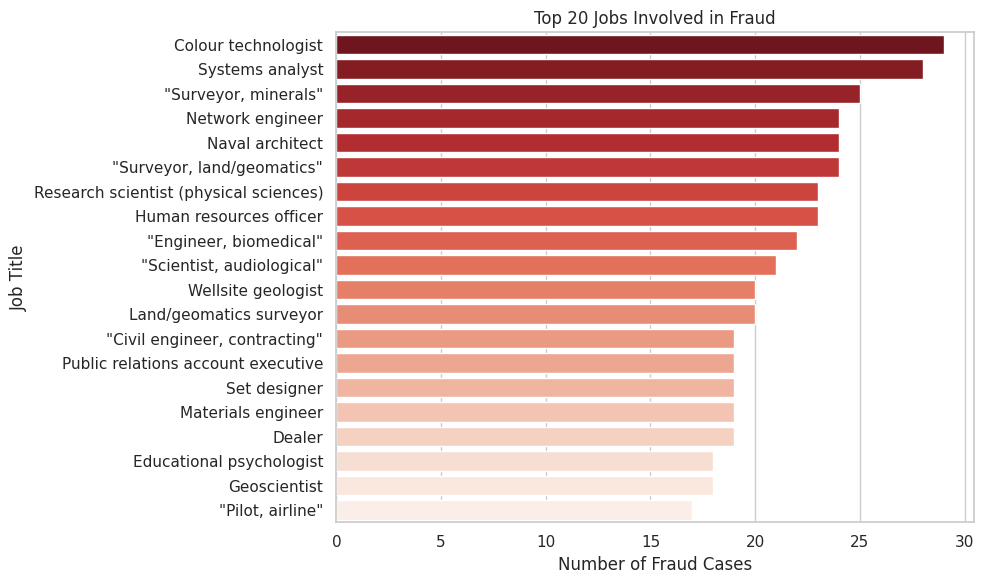

In [ ]:
# Count number of frauds per job
top_fraud_jobs = data_set[data_set['is_fraud'] == 1]['job'].value_counts().head(20)

# Display
print("Top 20 Jobs Involved in Fraud:")
print(top_fraud_jobs)

#Bar chart
plt.figure(figsize=(10, 6))
sns.barplot(y=top_fraud_jobs.index, x=top_fraud_jobs.values, palette='Reds_r')
plt.title('Top 20 Jobs Involved in Fraud')
plt.xlabel('Number of Fraud Cases')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

In [ ]:
def categorize_job(job):
    job = job.lower()

    if any(x in job for x in ['engineer', 'architect', 'technologist']):
        return 'Engineering'
    elif any(x in job for x in ['nurse', 'psychologist', 'therapist', 'pharmacist', 'medical', 'podiatrist', 'chiropodist', 'cytogeneticist', 'radiographer']):
        return 'Healthcare'
    elif any(x in job for x in ['it', 'systems', 'network', 'software', 'developer', 'consultant', 'analyst']):
        return 'IT & Tech'
    elif any(x in job for x in ['teacher', 'education', 'lecturer', 'professor', 'mentor', 'education administrator']):
        return 'Education'
    elif any(x in job for x in ['accountant', 'investment', 'banker', 'finance', 'legal', 'lawyer', 'solicitor', 'barrister']):
        return 'Finance & Legal'
    elif any(x in job for x in ['editor', 'journalist', 'writer', 'musician', 'artist', 'designer', 'video']):
        return 'Media & Arts'
    elif any(x in job for x in ['manager', 'executive', 'human resources', 'dealer', 'comptroller']):
        return 'Business & Management'
    elif any(x in job for x in ['scientist', 'research', 'geologist', 'physicist', 'biologist', 'minerals', 'geomatics', 'mining']):
        return 'Science & Research'
    elif any(x in job for x in ['sales', 'marketing', 'buyer', 'retail', 'chief marketing officer']):
        return 'Sales & Marketing'
    elif any(x in job for x in ['airline']):
      return 'Aviation'
    elif any(x in job for x in ['government', 'civil service', 'armed forces', 'museum', 'political', 'historic', 'immigration', 'nature conservation officer', 'inspector']):
      return 'Government'
    else:
        return 'Other'

# Apply to your dataframe
data_set['job_category'] = data_set['job'].apply(categorize_job)

print(data_set['job_category'].value_counts())

job_category
Engineering              2393
Other                    2038
Science & Research       2010
IT & Tech                1825
Healthcare               1704
Business & Management    1336
Education                1172
Government                639
Media & Arts              482
Finance & Legal           338
Sales & Marketing         222
Aviation                  222
Name: count, dtype: int64


In [ ]:
print(data_set['job_category'].dtype)

object


 Skipping 'merchant' — too many categories (693)


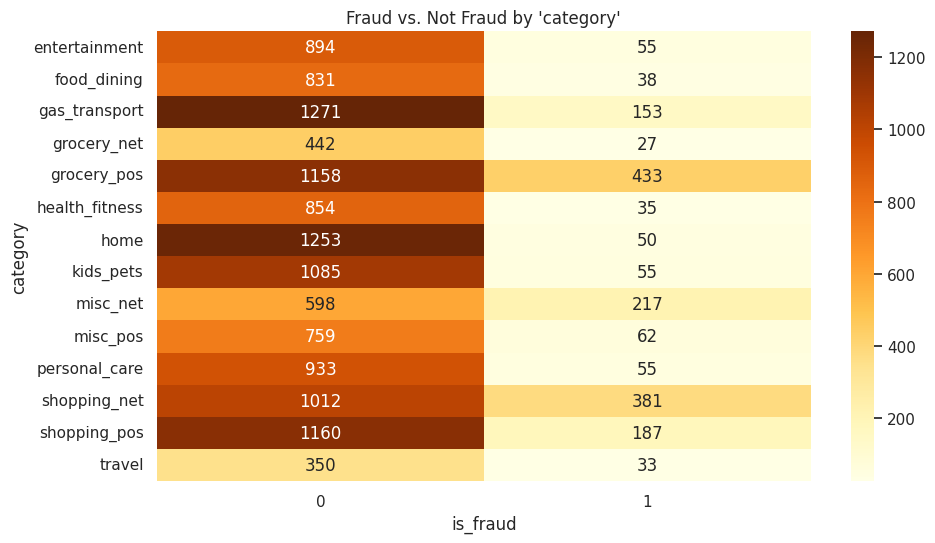

 Skipping 'city' — too many categories (176)


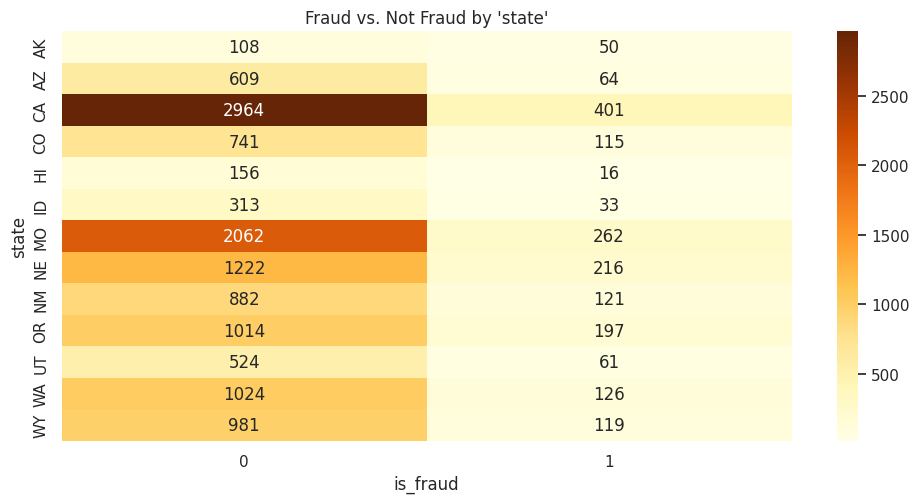

 Skipping 'job' — too many categories (163)
 Skipping 'trans_num' — too many categories (14381)


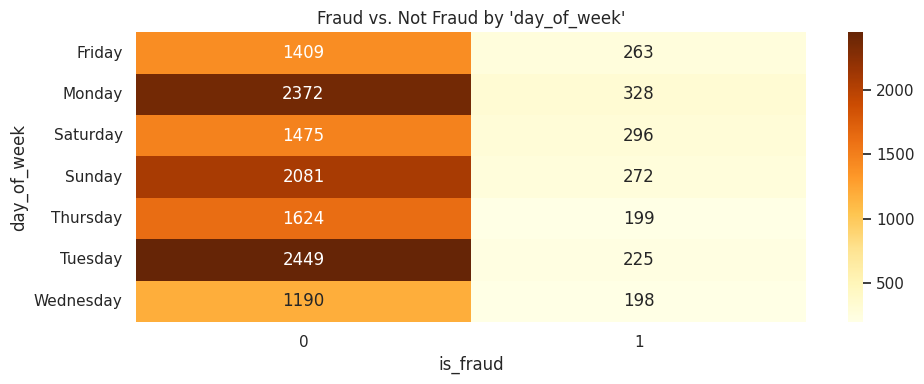

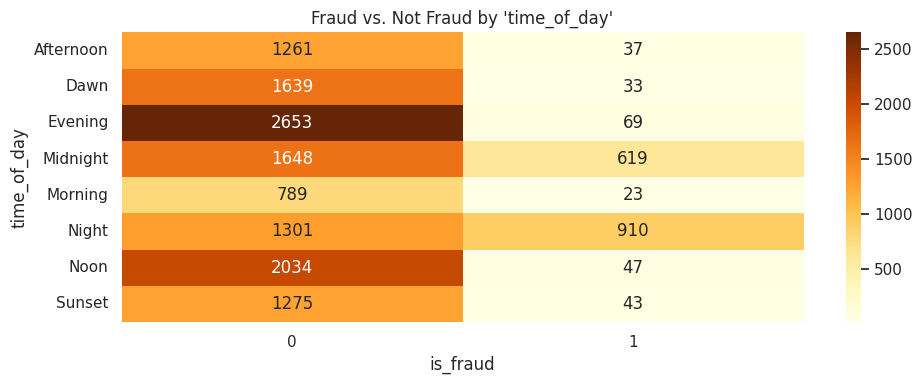

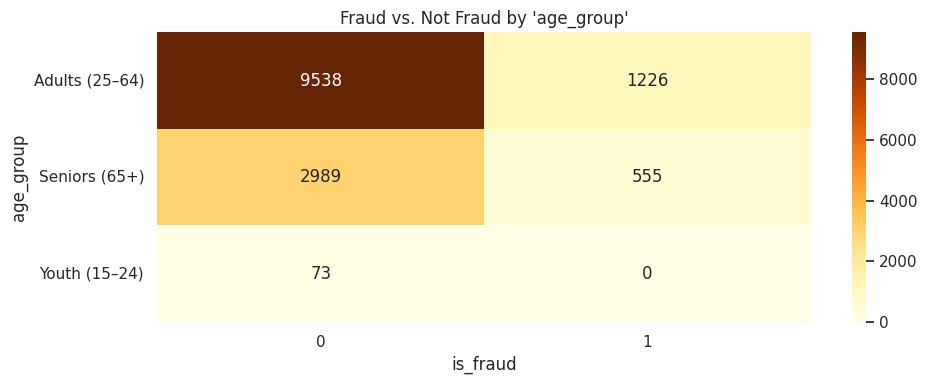

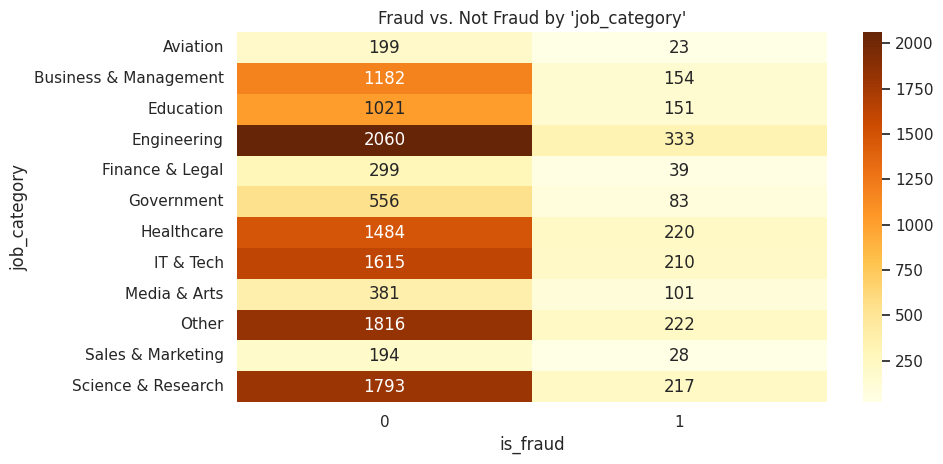

In [ ]:
# Get all categorical columns
categorical_cols = data_set.select_dtypes(include='object').columns

# Loop through each categorical column
for col in categorical_cols:
    # Create cross-tab (count of fraud vs not fraud for each category)
    fraud_ct = data_set.groupby([col, 'is_fraud']).size().unstack(fill_value=0)

    # Skip if too many unique values (for readability)
    if fraud_ct.shape[0] > 30:
        print(f" Skipping '{col}' — too many categories ({fraud_ct.shape[0]})")
        continue

    # Plot heatmap
    plt.figure(figsize=(10, max(4, fraud_ct.shape[0] * 0.4)))
    sns.heatmap(fraud_ct, annot=True, fmt='d', cmap='YlOrBr')
    plt.title(f"Fraud vs. Not Fraud by '{col}'")
    plt.xlabel("is_fraud")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

 Skipping 'merchant' — too many categories (693)


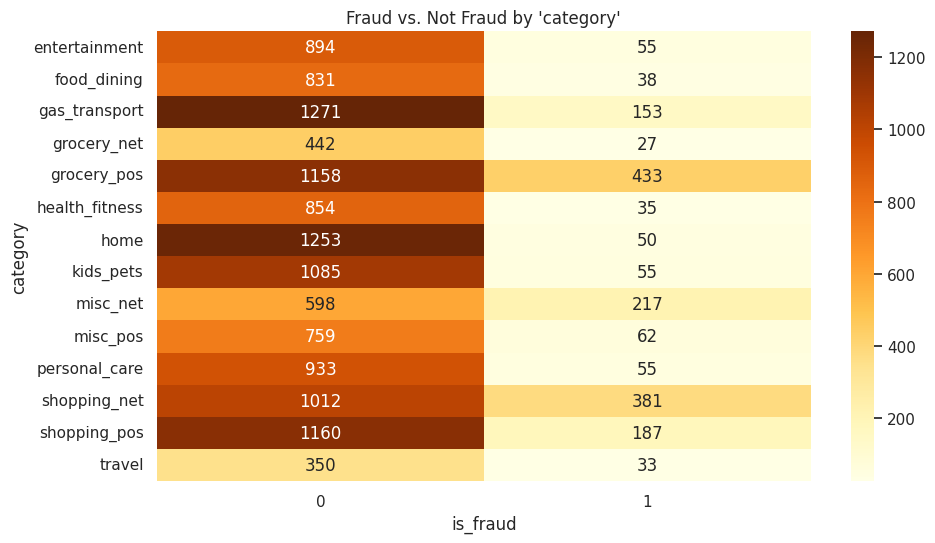

 Skipping 'city' — too many categories (176)


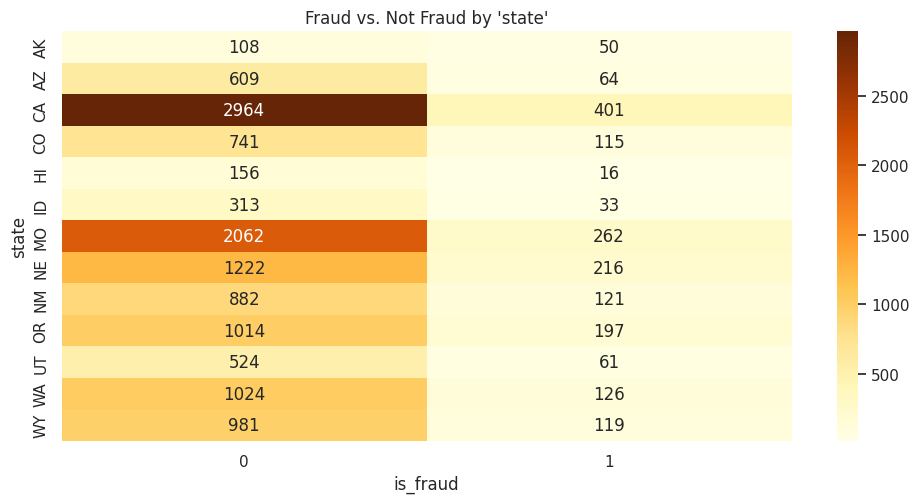

 Skipping 'job' — too many categories (163)
 Skipping 'trans_num' — too many categories (14381)


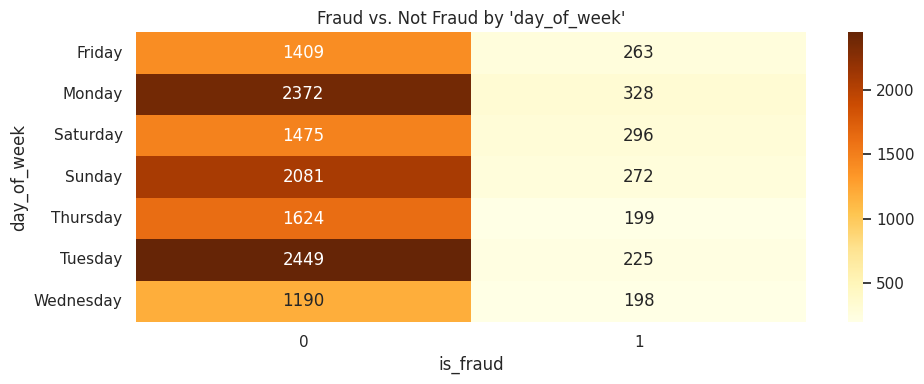

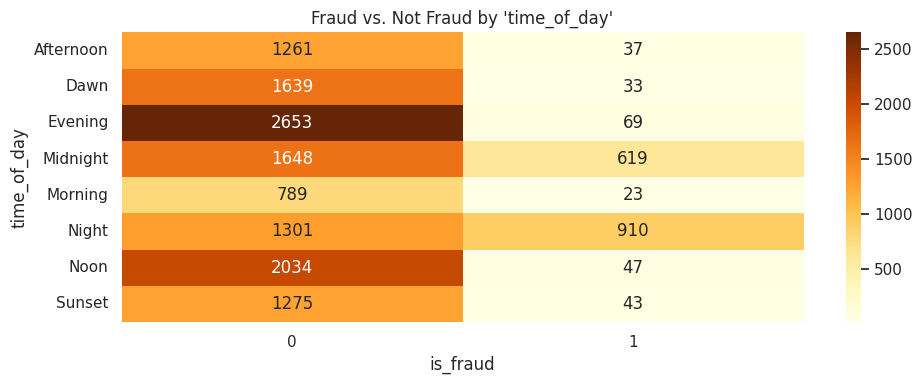

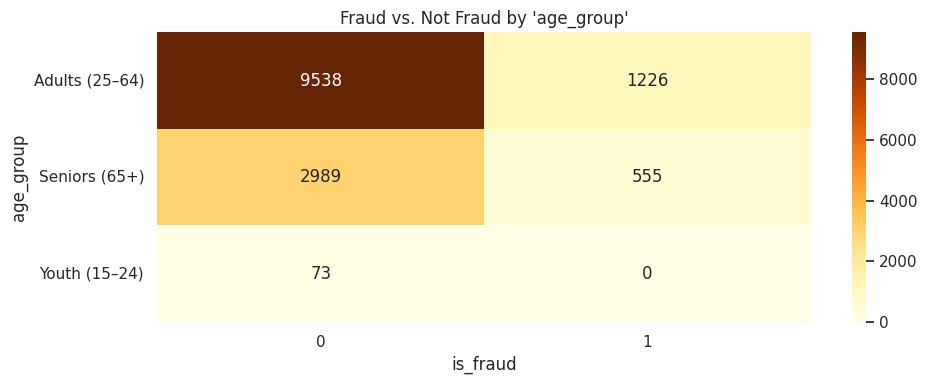

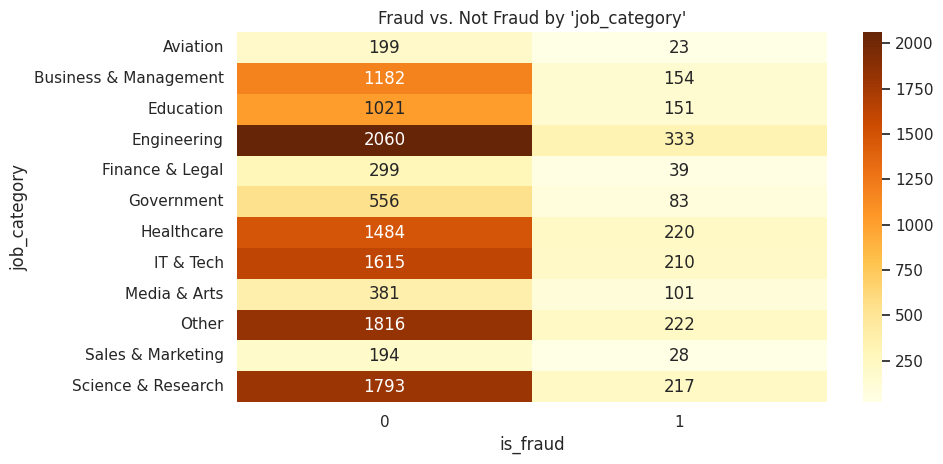

In [ ]:
# Get all categorical columns
categorical_cols = data_set.select_dtypes(include='object').columns

# Loop through each categorical column
for col in categorical_cols:
    # Create cross-tab (count of fraud vs not fraud for each category)
    fraud_ct = data_set.groupby([col, 'is_fraud']).size().unstack(fill_value=0)

    # Skip if too many unique values (for readability)
    if fraud_ct.shape[0] > 30:
        print(f" Skipping '{col}' — too many categories ({fraud_ct.shape[0]})")
        continue

    # Plot heatmap
    plt.figure(figsize=(10, max(4, fraud_ct.shape[0] * 0.4)))
    sns.heatmap(fraud_ct, annot=True, fmt='d', cmap='YlOrBr')
    plt.title(f"Fraud vs. Not Fraud by '{col}'")
    plt.xlabel("is_fraud")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

<Figure size 1500x800 with 0 Axes>

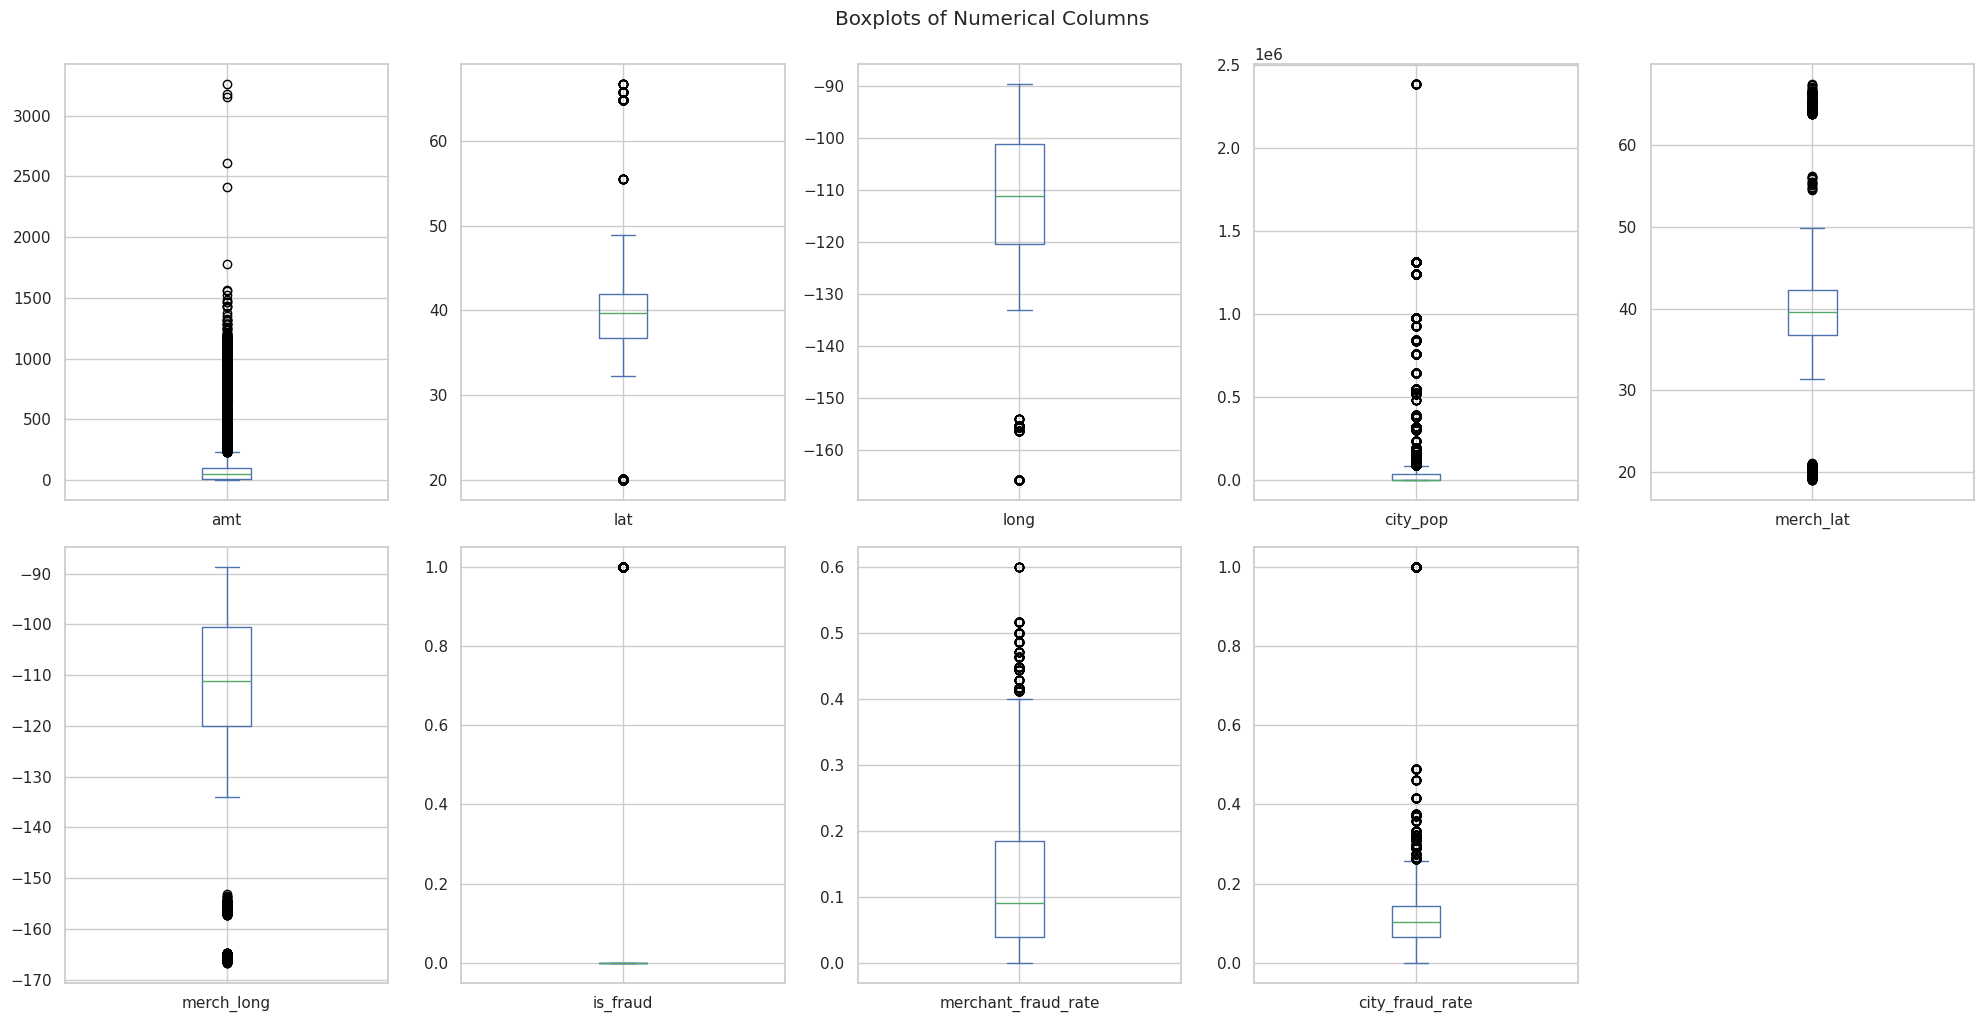

In [ ]:
# Select only numerical columns
numerical_cols = data_set.select_dtypes(include=['int64', 'float64']).columns

# Set up the plot size
plt.figure(figsize=(15, 8))

# Create boxplots
data_set[numerical_cols].plot(kind='box', subplots=True, layout=(2, len(numerical_cols)//2 + 1),
                              figsize=(20, 10), sharex=False, sharey=False)

plt.tight_layout()
plt.suptitle('Boxplots of Numerical Columns', y=1.02)
plt.show()

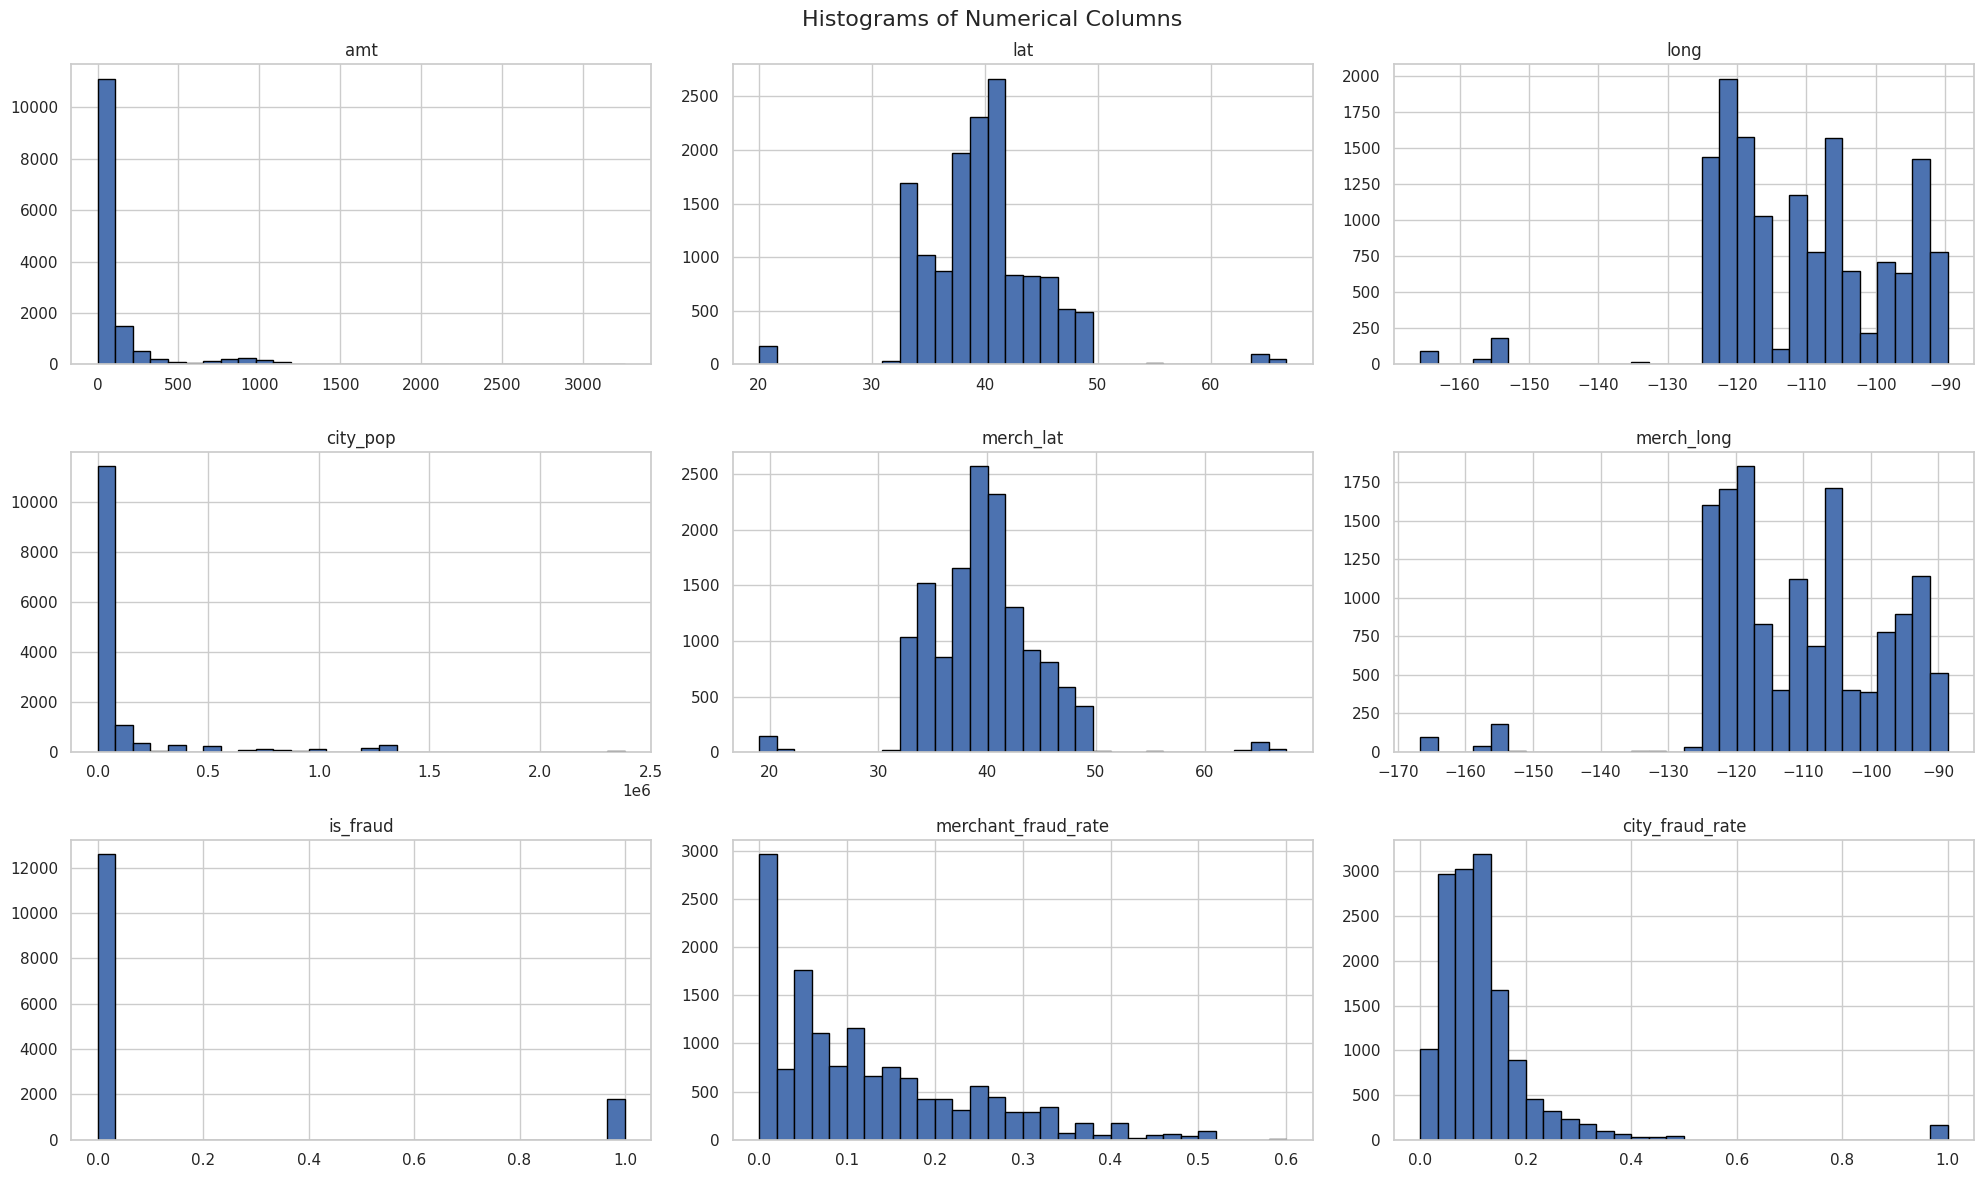

In [ ]:
# Select only numerical columns
numerical_cols = data_set.select_dtypes(include=['int64', 'float64']).columns

# Plot histogramsss
data_set[numerical_cols].hist(figsize=(20, 12), bins=30, edgecolor='black')
plt.suptitle('Histograms of Numerical Columns', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
data_set.head(2)

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,...,merch_long,is_fraud,age,day_of_week,hour,time_of_day,age_group,merchant_fraud_rate,city_fraud_rate,job_category
0,2019-01-01 00:00:00,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,...,-112.154481,0,63,Tuesday,0,Midnight,Adults (25–64),0.083333,0.258065,Government
1,2019-01-01 00:07:00,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,...,-122.230347,0,80,Tuesday,0,Midnight,Seniors (65+),0.333333,0.141304,IT & Tech


In [ ]:
data_set.dtypes

,0
trans_date_trans_time,datetime64[ns]
merchant,object
category,object
amt,float64
city,object
state,object
lat,float64
long,float64
city_pop,int64
job,object


In [ ]:
# See unique values and their counts in 'is_fraud'
print("Unique values in 'is_fraud':")
print(data_set['is_fraud'].value_counts())

# Or just see how many unique identifiers
print("\nNumber of unique values in 'is_fraud':", data_set['is_fraud'].nunique())

Unique values in 'is_fraud':
is_fraud
0    12600
1     1781
Name: count, dtype: int64

Number of unique values in 'is_fraud': 2


In [ ]:
from imblearn.pipeline import Pipeline  # Use imblearn's pipeline, not sklearn's
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split

# 1. Define features and target
X = data_set[[
    'category', 'state', 'day_of_week', 'time_of_day', 'age_group', 'job_category',
    'amt', 'lat', 'long', 'city_pop', 'merchant_fraud_rate', 'city_fraud_rate', 'age'
]]
y = data_set['is_fraud']

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Column types
categorical_features = ['category', 'state', 'day_of_week', 'time_of_day', 'age_group', 'job_category']
numerical_features = ['amt', 'lat', 'long', 'city_pop', 'merchant_fraud_rate', 'city_fraud_rate', 'age']

# 4. Preprocessor (no scaling since Random Forest doesn't need it)
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', 'passthrough', numerical_features)  # Pass numeric features without scaling
])

# 5. Create SMOTE + model pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 6. Hyperparameter grid
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# 7. GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)

# 8. Fit on training data
grid_search.fit(X_train, y_train)

# 9. Best parameters
print("Best hyperparameters:", grid_search.best_params_)
print("Best F1 score (CV):", grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best hyperparameters: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best F1 score (CV): 0.9024124739001884



 Classification Report:
              precision    recall  f1-score   support

           0     0.9831    0.9933    0.9882      2521
           1     0.9485    0.8792    0.9125       356

    accuracy                         0.9791      2877
   macro avg     0.9658    0.9362    0.9503      2877
weighted avg     0.9788    0.9791    0.9788      2877

 Accuracy: 0.9791
 Precision: 0.9485
 Recall: 0.8792
 F1 Score: 0.9125


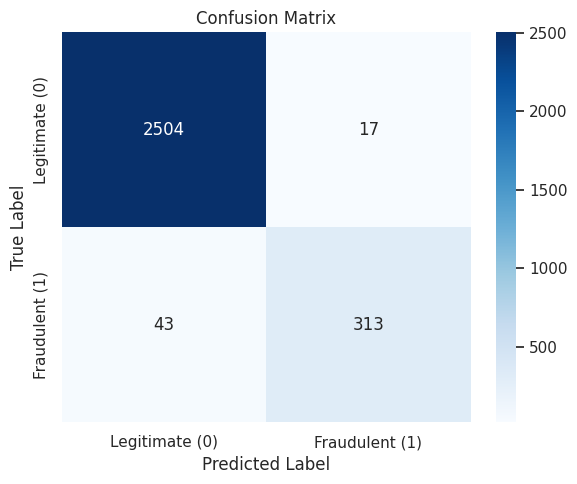

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# 1. Build final pipeline using best parameters
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ))
])

# 2. Fit model on training data
final_pipeline.fit(X_train, y_train)

# 3. Predict on test set
y_pred = final_pipeline.predict(X_test)

# 4. Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# 5. Print results
print("\n Classification Report:")
print(classification_report(y_test, y_pred, digits=4))
print(" Accuracy:", round(accuracy, 4))
print(" Precision:", round(precision, 4))
print(" Recall:", round(recall, 4))
print(" F1 Score:", round(f1, 4))

# 6. Confusion matrix visualization
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate (0)', 'Fraudulent (1)'],
            yticklabels=['Legitimate (0)', 'Fraudulent (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


In [ ]:
from collections import Counter
from imblearn.over_sampling import SMOTE

# 1. Show class distribution before SMOTE
print(" Class distribution before SMOTE:")
print(Counter(y_train))

# 2. Manually apply preprocessing (convert to dense array)
X_train_encoded = preprocessor.fit_transform(X_train).toarray()

# 3. Apply SMOTE
X_resampled, y_resampled = SMOTE(random_state=42).fit_resample(X_train_encoded, y_train)

# 4. Show class distribution after SMOTE
print("\n Class distribution after SMOTE:")
print(Counter(y_resampled))

 Class distribution before SMOTE:
Counter({0: 10079, 1: 1425})

 Class distribution after SMOTE:
Counter({0: 10079, 1: 10079})


In [ ]:
data_set.to_csv('processed_fraud_data.csv', index=False)
from google.colab import files
files.download('processed_fraud_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Skipping 'merchant' — too many categories (693)


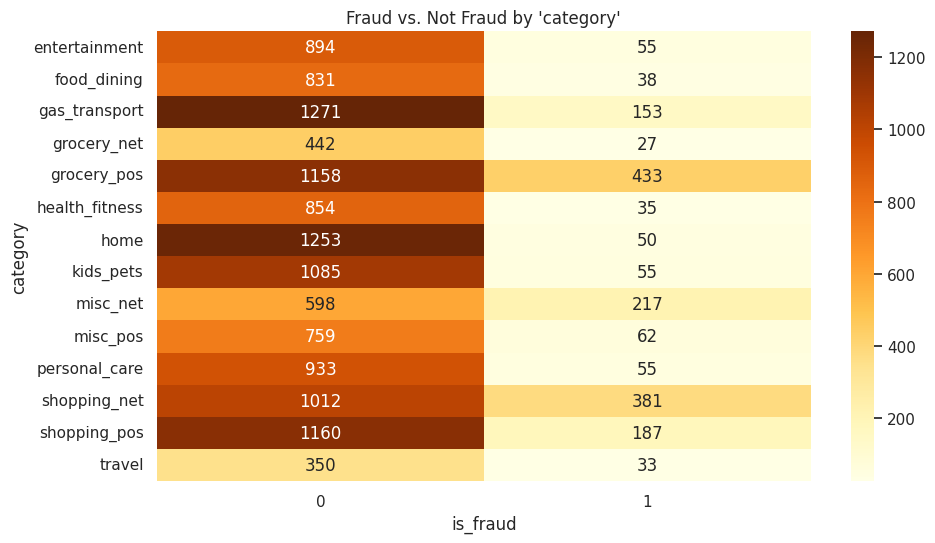

 Skipping 'city' — too many categories (176)


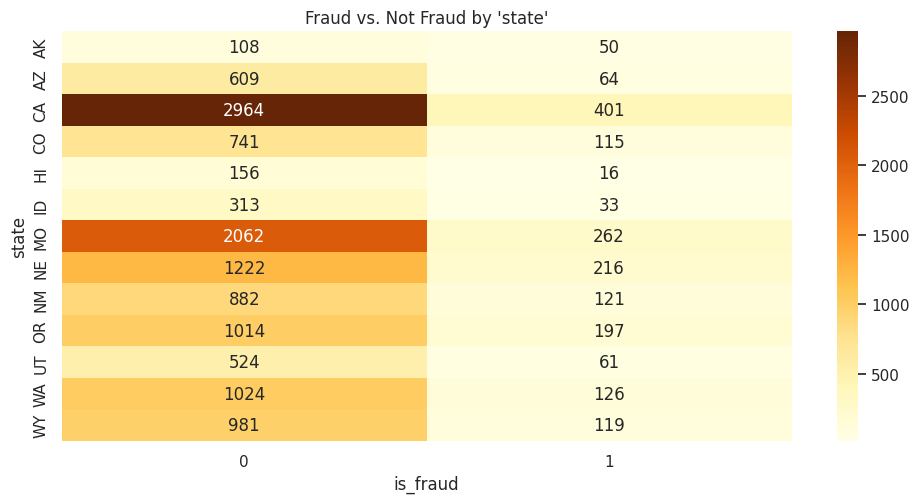

 Skipping 'job' — too many categories (163)
 Skipping 'trans_num' — too many categories (14381)


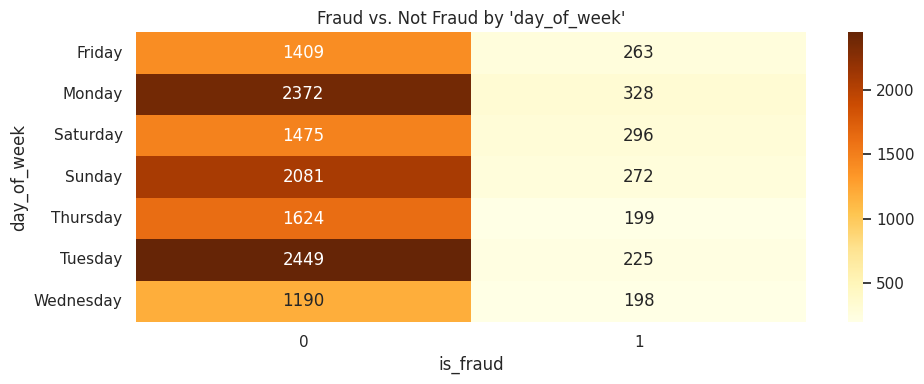

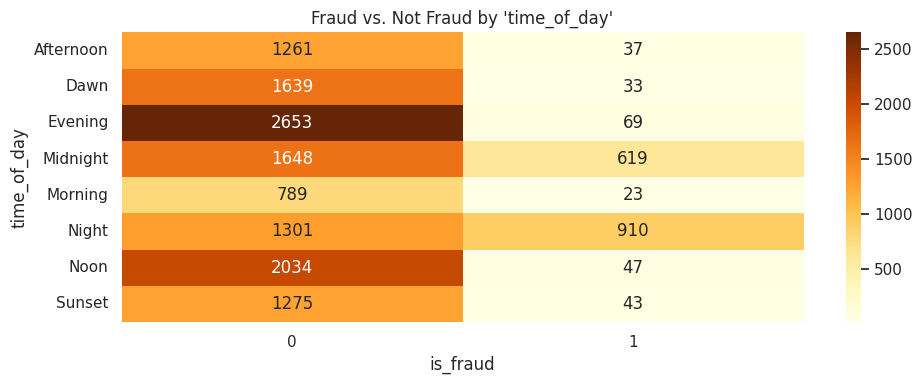

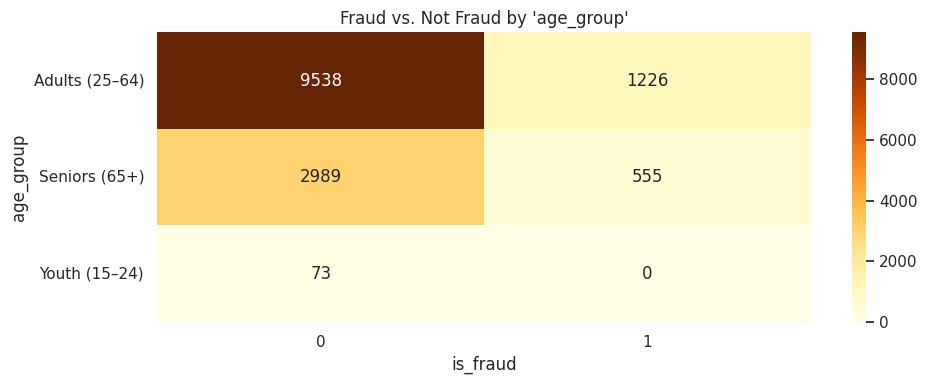

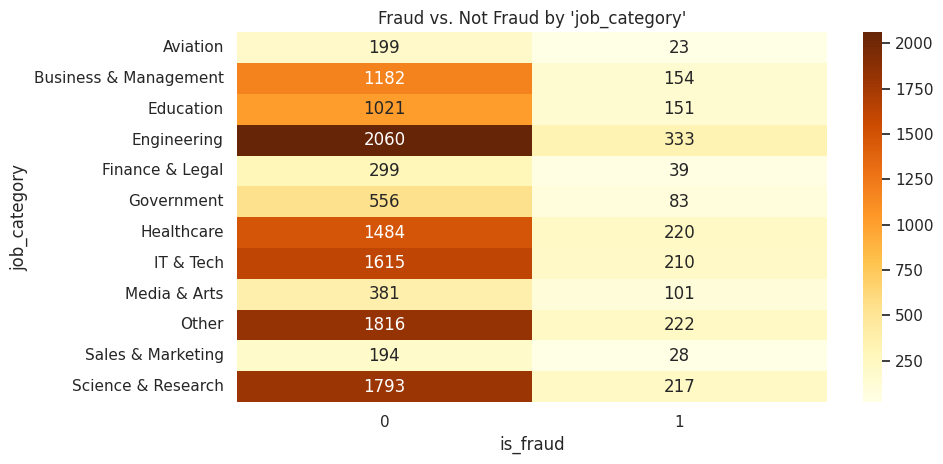

In [ ]:
# Get all categorical columns
categorical_cols = data_set.select_dtypes(include='object').columns

# Loop through each categorical column
for col in categorical_cols:
    # Create cross-tab (count of fraud vs not fraud for each category)
    fraud_ct = data_set.groupby([col, 'is_fraud']).size().unstack(fill_value=0)

    # Skip if too many unique values (for readability)
    if fraud_ct.shape[0] > 30:
        print(f" Skipping '{col}' — too many categories ({fraud_ct.shape[0]})")
        continue

    # Plot heatmap
    plt.figure(figsize=(10, max(4, fraud_ct.shape[0] * 0.4)))
    sns.heatmap(fraud_ct, annot=True, fmt='d', cmap='YlOrBr')
    plt.title(f"Fraud vs. Not Fraud by '{col}'")
    plt.xlabel("is_fraud")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [ ]:
# Descriptive stats for fraud and non-fraud
data_set.groupby('is_fraud')['amt'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,12600.0,66.814898,114.481015,1.00,9.77,46.14,81.9275,3261.47
1,1781.0,518.345424,389.557509,1.78,218.81,357.50,884.7500,1371.81
